In [14]:
from qat.fermion.hamiltonians import FermionHamiltonian, SpinHamiltonian, make_anderson_model
from qat.fermion.trotterisation import make_trotterisation_routine
from qat.lang import *
from qat.core import Term, Observable
from qat.hardware import DefaultHardwareModel, make_depolarizing_hardware_model
from qat.qpus import get_default_qpu, CLinalg

from scipy.optimize import minimize
from qat.lang.AQASM import QRoutine

import numpy as np

import matplotlib.pyplot as plt
from collections import deque

from scipy.optimize import minimize
from scipy.linalg import expm, eigh
from scipy.integrate import simpson

from typing import List
from tqdm import tqdm


In [2]:
'''eps1 = 0.01
eps2 = 0.1
hw_model = make_depolarizing_hardware_model(eps1=eps1, eps2=eps2, depol_type="randomizing", correl_type="multi_qubit")
noisy_qpu = CLinalg(hardware_model=hw_model, sim_method="deterministic-vectorized")'''

'eps1 = 0.01\neps2 = 0.1\nhw_model = make_depolarizing_hardware_model(eps1=eps1, eps2=eps2, depol_type="randomizing", correl_type="multi_qubit")\nnoisy_qpu = CLinalg(hardware_model=hw_model, sim_method="deterministic-vectorized")'

On commence d'abord par définir l'opérateur $c^{\dagger}_{i, \sigma1}c_{j, \sigma2}$ qui va être utilisé pour définir le hamiltonien :

In [2]:
#Definition de l'operateur  
def couplingOp(n_qubits: int, energy: float, i: int, j: int, spin_i: str, spin_j: str) : 
    """ Calcule une instance de FermionHamiltonian associée à l'opérateur c^{dagger}_{i, sigma1}c_{j, sigma2}, 
    i et j sont les numéros de site, energy est le préfacteur énergétique apparaissant dans 
    la définition du hamiltonien. """
    if spin_i == "+" :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j])])
    else :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j])]) 
        
def nOp(n_qubits, energy, i, spin) :
    """Calcule une instance de FermionHamiltonian associée à l'opérateur n_{i, spin} avec le préfacteur energy."""
    return couplingOp(n_qubits, energy, i, i, spin, spin)
    

In [3]:
print(couplingOp(4,2,1,2,"+","-"))
print((couplingOp(4,1,0,0,"-","-")))


2 * (Cc|[1, 3])
1 * (Cc|[1, 1])


Definition de l'Hamiltonien de Anderson (avec la possibilité de choisir le nombre d'impuretés contrairement à la fonction make_anderson_model de myQLM)

In [4]:
#Definition de l'hamiltonien
def hamiltonian(n_impurities: int, n_bain: int, U: float, mu: float, t: float, V, epsilon: list) :
    """ Calcule le hamiltonien du modèle d'Anderson et le renvoie sous la forme 
    du couple (SpinHamiltonian, matrice associée)."""
    n_qubits = 2 * n_bain + 2 * n_impurities
    H_repulsion = 0
    H_hopping = 0
    H_chem = 0
    for wire in range(0, 2*n_impurities, 2) :
        #Calcul du terme de potentiel chimique
        H_chem += nOp(n_qubits, -mu, wire, "+")
        H_chem += nOp(n_qubits, -mu, wire, "-")

        #Calcul du terme d'effet tunnel entre impuretés, dit "hopping"
        for wire2 in range(0, 2*n_impurities, 2) :
            if wire2 != wire :
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "+")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "+")
            else :
                #Calcul du terme de répulsion coulombienne
                H_repulsion += nOp(n_qubits, U, wire, "+")*nOp(n_qubits, 1, wire,"-")
    
    H_impurity_bath = 0
    H_bath = 0
    for wire3 in range(2*n_impurities, n_qubits, 2) :
        i = (wire3 - 2*n_impurities) // 2
        e = epsilon[i]
        #Calcul du terme lié au bain
        H_bath += nOp(n_qubits, e, wire3, "+")
        H_bath += nOp(n_qubits, e, wire3, "-")
        
        for wire4 in range(0, 2*n_impurities, 2) :
            #Calcul du terme d'interaction impureté-bain
            j = wire4 // 2
            v = V[j][i]
            vstar = v if np.isreal(v) else np.conj(v)
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "+", "+") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "+", "+")
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "-", "-") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "-", "-")
        

    H_anderson = H_repulsion + H_chem + H_impurity_bath + H_bath + H_hopping
    H_spin = H_anderson.to_spin(method = "jordan-wigner")#Fermion to Qubit
    return H_spin, H_spin.get_matrix()


In [5]:
H_2bain = hamiltonian(1,2,1,1,0,[[1, 2]], [1, 2])
print(H_2bain[0])

(2.25+0j) * I^6 +
(0.25+0j) * (ZZ|[0, 1]) +
(0.25+0j) * (Z|[0]) +
(0.25+0j) * (Z|[1]) +
(0.5+0j) * (XZX|[0, 1, 2]) +
(0.5+0j) * (YZY|[0, 1, 2]) +
(0.5+0j) * (XZX|[1, 2, 3]) +
(0.5+0j) * (YZY|[1, 2, 3]) +
(1+0j) * (XZZZX|[0, 1, 2, 3, 4]) +
(1+0j) * (YZZZY|[0, 1, 2, 3, 4]) +
(1+0j) * (XZZZX|[1, 2, 3, 4, 5]) +
(1+0j) * (YZZZY|[1, 2, 3, 4, 5]) +
(-0.5+0j) * (Z|[2]) +
(-0.5+0j) * (Z|[3]) +
(-1+0j) * (Z|[4]) +
(-1+0j) * (Z|[5])


In [6]:
H_test= SpinHamiltonian(1, [Term(1/np.sqrt(2), "Z", [0]), Term(1/np.sqrt(2), "X", [0])])
print(H_test)


0.7071067811865475 * (Z|[0]) +
0.7071067811865475 * (X|[0])


In [7]:
And, matr = hamiltonian(1,1,1,1,0,[[1]], [1])
print(And)

(0.25+0j) * I^4 +
(0.25+0j) * (ZZ|[0, 1]) +
(0.25+0j) * (Z|[0]) +
(0.25+0j) * (Z|[1]) +
(0.5+0j) * (XZX|[0, 1, 2]) +
(0.5+0j) * (YZY|[0, 1, 2]) +
(0.5+0j) * (XZX|[1, 2, 3]) +
(0.5+0j) * (YZY|[1, 2, 3]) +
(-0.5+0j) * (Z|[2]) +
(-0.5+0j) * (Z|[3])


In [8]:

H_1 = SpinHamiltonian(4, [Term(-1, "ZZ", [0,1]), Term(-1, "ZZ", [1,2]), 
                                     Term(-1, "ZZ", [2,3]), Term(-1, "ZZ", [0,3])])

AndersonHamiltonian, matrix = hamiltonian(1, 1, 1, 1, 0, [[1]], [1]) 
print(np.linalg.eigvals(matrix))

[-2.17740968e+00+0.j  3.21637174e-01+0.j  2.85577251e+00+0.j
  1.41421356e+00+0.j -1.41421356e+00+0.j  1.41421356e+00+0.j
 -1.41421356e+00+0.j -6.18033989e-01+0.j  3.14010730e-17+0.j
  1.61803399e+00+0.j -6.18033989e-01+0.j  1.61803399e+00+0.j
  0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  1.00000000e+00+0.j]


In [9]:
H_0, matrixH_0 = hamiltonian(1, 1, 1, 1, 0, [[0]], [1])
AndersonHamiltonian, matrix =  hamiltonian(1, 1, 1, 1, 1, [[1]], [1])

eigvals, eigvectors = eigh(matrix)
print("energie fondamental anderson", eigvals[0])

H_1 = SpinHamiltonian(4, [Term(1, "X", [i]) for i in range(4)])
eigval, eigvector = eigh(H_1.get_matrix())
print(eigval[0])
print(eigvector[:,0])

'''H = sum(Observable.sigma_x(i,4) for i in range(4)).to_spin()
'''
print(H_1)
print(type(H_1))

energie fondamental anderson -2.1774096808992796
-3.9999999999999893
[ 0.25-0.j -0.25+0.j -0.25+0.j  0.25+0.j -0.25+0.j  0.25+0.j  0.25+0.j
 -0.25+0.j -0.25+0.j  0.25+0.j  0.25+0.j -0.25+0.j  0.25+0.j -0.25+0.j
 -0.25+0.j  0.25+0.j]
1 * (X|[0]) +
1 * (X|[1]) +
1 * (X|[2]) +
1 * (X|[3])
<class 'qat.fermion.hamiltonians.SpinHamiltonian'>


<h3>Implementation du HVA pour passer d'un hamiltonien connu (diagonalisable) à notre hamiltonien d'Anderson</h3>

In [13]:
def hva_ansatz(psi_0, depth, hamiltonians,
                h_target, n_steps,  params) : #prend des hamiltoniens de spin et simule un recuit quantique
    k = len(hamiltonians)
    n = h_target.nbqbits
    rout = QRoutine()
    rout.apply(psi_0, [range(n)])
    for i in range(depth) :
        routTarget = make_trotterisation_routine(h_target, 
                                                n_trotter_steps = n_steps, 
                                                final_time = params[(k+1)*i + k])
        rout.apply(routTarget, [range(n)])
        for j in range(k) :
            rout1 = make_trotterisation_routine(hamiltonians[j], 
                                                    n_trotter_steps=n_steps,
                                                    final_time= params[(k+1)*i + j])
            rout.apply(rout1, [range(n)])
            
    return rout

def cost_function(psi0, depth, hamiltonians,
                h_target, n_steps,  params) :
    
    job = hva_ansatz(psi0, depth, hamiltonians,
                h_target, n_steps,  params).to_job(observable = h_target)
    qpu = get_default_qpu()
    result = qpu.submit(job)
    return result.value


In [11]:
def hva_optimization_loop(psi_0, depth: int, hamiltonians: List[SpinHamiltonian], h_target: SpinHamiltonian,
                           n_steps: int, init_params: np.ndarray) :
    '''plot la courbe d'énergie, renvoie un dictionnaire avec l'énergie fondamentale et un circuit quantique préparant l'état fondamental'''
    variational_circuit = lambda param: cost_function(psi_0, depth, hamiltonians, h_target, n_steps, param)
    function_values = []

    def callback(params) :
        function_values.append(variational_circuit(params))
    
    ground_state_energy = minimize(variational_circuit, x0=init_params,
                                    method='COBYLA', callback=callback, options={'maxiter': 200})
    
    plt.plot(function_values, label=f'Energie pour profondeur={depth} et n_steps={n_steps}')
    plt.xlabel('Iteration')
    plt.ylabel('Energie')
    plt.title("Evolution de l'énergie lors de l'optimisation")
    plt.legend()

    return {"energie" : ground_state_energy.fun, 
            "circuit" : hva_ansatz(psi_0, depth=depth, hamiltonians=hamiltonians, 
                  h_target=h_target, n_steps=n_steps, params=ground_state_energy.x)}



<h2>Test avec différents hamiltoniens de départ</h2>

In [12]:
initial_params=np.array([1, 0]*10)

### $\sum Z_{i-1}X_{i}Z_{i+1}$

In [55]:
H_cluster = SpinHamiltonian(4, [Term(1, "ZXZ", [i-1,i,i+1]) for i in range(1,3)])
eigval, eigvector = eigh(H_cluster.get_matrix())
print(eigval[0])
print(eigvector[:,0])


-1.999999999999997
[ 0.5-0.j  0. +0.j -0.5+0.j  0. +0.j -0.5+0.j  0. +0.j -0.5+0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]


### $X_1 + X_2 + X_3 + X_4$

In [19]:
H_x = SpinHamiltonian(4, [Term(1, "X", [i]) for i in range(4)])

initial_state = QRoutine()
for wire in range(4) :
    initial_state.apply(H, wire)
    initial_state.apply(Z, wire)

-0.6518000971497689
-0.633587678187883
-0.6243535012174387
-0.6225073234733349
-1.4929570259909324
-1.4507393424690271
-1.4255830109808327
-1.3977879694061277
-1.755176382099001
-1.8153123353279947
-1.7666543459315318
-1.8196170901280664
-1.6798452597216111
-1.4548207089519625
-1.6231888674419412
-1.4858548626864305
-1.650190900766633
-1.5145197190066177
-1.5569182215419077
-1.7752876631760217


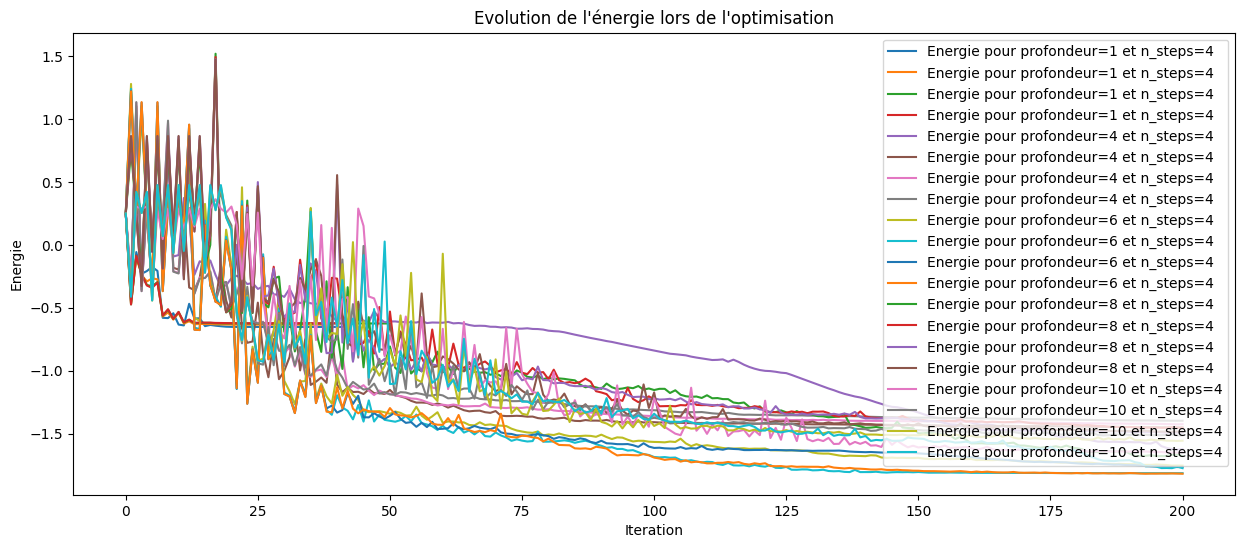

|Psi>
{'0000': (-0.01956823019659813-0.05588129701832967j), '0001': (0.09028343401468363+0.05555483111604746j), '0010': (-0.01951445404394558+0.12036123646784813j), '0011': (0.1117867400579005+0.06985138576198222j), '0100': (-0.14693700341574928-0.03560953762794728j), '0101': (0.031088359326288267+0.10639875480372973j), '0110': (0.1431260103300583+0.3881287050363081j), '0111': (0.0049149456695442425-0.010609780189130669j), '1000': (0.05402174483347798-0.17940110513122662j), '1001': (-0.10909288058617675-0.22120814604419206j), '1010': (0.0029447704175939167+0.06052180418838398j), '1011': (-0.00576699005963675-0.056034331881150375j), '1100': (0.2625462039349479+0.7086615506905793j), '1101': (0.07699496855586682-0.17689919327144535j), '1110': (-0.0530968386364115-0.11028214880337206j), '1111': (-0.048597174279495454+0.13462535295246222j)}


In [ ]:
energie_circuit = None
plt.figure(figsize=(15,6))
for depth in [1, 4, 6, 8, 10] :
    for n_trotter_steps in [2, 4, 8, 10] :
        energie_circuit = hva_optimization_loop(psi_0=initial_state, depth=depth, hamiltonians=[H_x], h_target=AndersonHamiltonian,
                           n_steps=n_trotter_steps, init_params=initial_params[:2*depth])
        print(energie_circuit["energie"])
        
plt.show()
psi0 = energie_circuit["circuit"]
psi0.display()
job = psi0.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)


Test avec autres paramètres du hamiltonien

In [23]:
and_hamiltonian_U_small, mat_U_small = hamiltonian(1, 1, 0, 1, 0, [[1]], [1])
and_hamiltonian_U_big, mat_U_big = hamiltonian(1, 1, 10, 1, 0, [[1]], [1])

In [24]:
eigval_U_small, eigvect_U_small = eigh(mat_U_small)
print("énergie du fondamental exacte", eigval_U_small[0])
print("état fondamental exact", eigvect_U_small[:,0])

énergie du fondamental exacte -2.828427124746184
état fondamental exact [ 0.        +0.j  0.        +0.j  0.        +0.j  0.14644661+0.j
  0.        +0.j  0.        +0.j  0.35355339+0.j  0.        +0.j
  0.        +0.j -0.35355339+0.j  0.        +0.j  0.        +0.j
  0.85355339+0.j  0.        +0.j  0.        +0.j  0.        +0.j]


In [ ]:
energie_circuit = None
plt.figure(figsize=(15,6))
for depth in tqdm([1, 4, 6, 8, 10]) :
    for n_trotter_steps in [2, 4, 8, 10] :
        energie_circuit = hva_optimization_loop(psi_0=initial_state, depth=depth, hamiltonians=[H_x], h_target=and_hamiltonian_U_small,
                           n_steps=n_trotter_steps, init_params=initial_params[:2*depth])
        print(energie_circuit["energie"])
        
plt.show()
psi0_U_small = energie_circuit["circuit"]
psi0_U_small.display()
job = psi0_U_small.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict_U_small = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict_U_small)

  0%|          | 0/5 [00:00<?, ?it/s]

-1.3079417627831793
-1.386824537375337
-1.4073873018704877


 20%|██        | 1/5 [00:48<03:12, 48.08s/it]

-1.4098471419134992
-2.40912232726945
-2.6755318366455683
-2.3711950506018464


In [ ]:
eigval_U_big, eigvect_U_big = eigh(mat_U_big)
print("énergie du fondamental exacte (régime U grand)", eigval_U_big[0])
print("état fondamental exact (régime U grand)", eigvect_U_big[:,0])

In [ ]:
energie_circuit = None
plt.figure(figsize=(15,6))
for depth in tqdm([1, 4, 6, 8, 10]) :
    for n_trotter_steps in [2, 4, 8, 10] :
        energie_circuit = hva_optimization_loop(psi_0=initial_state, depth=depth, hamiltonians=[H_x], h_target=and_hamiltonian_U_big,
                           n_steps=n_trotter_steps, init_params=initial_params[:2*depth])
        print(energie_circuit["energie"])
        
plt.show()
psi0_U_small = energie_circuit["circuit"]
psi0_U_small.display()
job = psi0_U_small.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict_U_small = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict_U_small)

### $Z_1 + Z_2 + Z_3 + Z_4$



In [66]:
H_z = SpinHamiltonian(4, [Term(1, "Z", [i]) for i in range(4)])
eigval_z, eigvect_z = eigh(H_z.get_matrix())
print(eigval_z[0])
print(eigvect_z[:,0])


-4.0
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]


4.364293326730717e-08
4.3642934266507893e-08
4.364293670899855e-08
-0.4954130782794033
-0.6381527280952052
-0.6566467326999827
-0.9652239913989273
-1.1144378921261917
-0.2880533653780044
-1.3530557792401539
-0.9269022162845162
-1.127915202772142


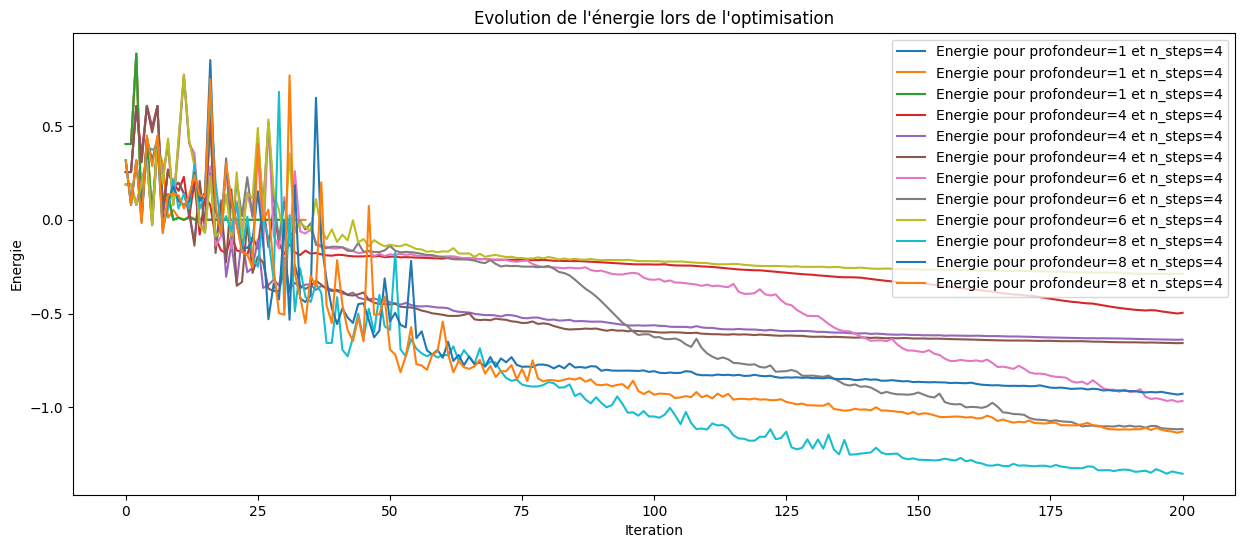

|Psi>
{'0000': (0.35945154762934006-0.17265218277751143j), '0001': (-0.017228869467003402-0.19247540974982222j), '0010': (-0.07867179798135183+0.10421644812084675j), '0011': (-0.10001005171529986+0.20425728211443195j), '0100': (-0.11175400297039252+0.2751508977990746j), '0101': (0.06825754078671652+0.13470198960537677j), '0110': (-0.10039771247501014+0.4443052274732991j), '0111': (0.1208386840804711-0.07978572190528317j), '1000': (0.02601297254055648-0.06358366324454943j), '1001': (0.32563511499830466-0.22663039710702523j), '1010': (0.15697986173657863+0.08297284076089771j), '1011': (0.0796401404613197+0.011368767884350142j), '1100': (-0.14273332337731803+0.3457121296973336j), '1101': (0.05624820559535845-0.14776400233945808j), '1110': (0.04373729283840641-0.03661077747950597j), '1111': (0.09267707530049195-0.13625481964106964j)}


In [72]:
initial_state_z = QRoutine()
for wire in range(4) :
    initial_state_z.apply(X, wire)

energie_circuit = None
plt.figure(figsize=(15,6))
for depth in [1, 4, 6, 8] :
    for n_trotter_steps in [2, 4, 8] :
        energie_circuit = hva_optimization_loop(psi_0=initial_state_z, depth=depth, hamiltonians=[H_x], h_target=AndersonHamiltonian,
                           n_steps=n_trotter_steps, init_params=initial_params[:2*depth])
        print(energie_circuit["energie"])
        
plt.show()
psi0 = energie_circuit["circuit"]
psi0.display()
job = psi0.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)

In [ ]:
rg

<h2>Non interacting AIM :</h2>

In [ ]:
anderson_U_0, matrice_U_0 = hamiltonian(1, 2, 0, 1, 0, [[2, 10]], [0, 0])
eigval_U_0, eigvect_U_0 = eigh(matrice_U_0)
print(eigval_U_0[0])
print(anderson_U_0.terms)

-21.420577856662142
Term(qbits=[0], op='Z', _coeff=TNumber(is_abstract=False, type=5, int_p=None, double_p=None, string_p=None, matrix_p=None, serialized_p=None, complex_p=ComplexNumber(re=0.5, im=0.0)), _do_validity_check=True)


In [174]:
anderson_U_0, matrice_U_0 = hamiltonian(1, 2, 0, 1, 0, [[2, 10]], [0, 0])
eigval_U_0, eigvect_U_0 = eigh(matrice_U_0)
print(eigval_U_0[0])
print(anderson_U_0.terms[0])

-21.420577856662142
Term(qbits=[0], op='Z', _coeff=TNumber(is_abstract=False, type=5, int_p=None, double_p=None, string_p=None, matrix_p=None, serialized_p=None, complex_p=ComplexNumber(re=0.5, im=0.0)), _do_validity_check=True)


In [ ]:
def parse_hamiltonian(h) :
    '''prend un hamiltonien et renvoie une liste python des opérateurs apapraissant dans la somme
    ainsi que les qubits sur lesquels ils agissent'''
    qubits_operators = []
    for term in h.terms :
        qubits_operators.append((term.qbits,term.op))
    return qubits_operators

print(parse_hamiltonian(AndersonHamiltonian))

[([0, 1], 'ZZ'), ([0], 'Z'), ([1], 'Z'), ([0, 1, 2], 'XZX'), ([0, 1, 2], 'YZY'), ([1, 2, 3], 'XZX'), ([1, 2, 3], 'YZY'), ([2], 'Z'), ([3], 'Z')]


énergie du fondamental estimée sans terme d'interaction -1.3079417627831793
énergie du fondamental estimée sans terme d'interaction -1.386824548009988
énergie du fondamental estimée sans terme d'interaction -1.4073873019728897
énergie du fondamental estimée sans terme d'interaction -2.3448474895493745
énergie du fondamental estimée sans terme d'interaction -2.675531837736407
énergie du fondamental estimée sans terme d'interaction -2.371195050625672
énergie du fondamental estimée sans terme d'interaction -2.626040401323916
énergie du fondamental estimée sans terme d'interaction -2.616032373365842
énergie du fondamental estimée sans terme d'interaction -2.668093255152909


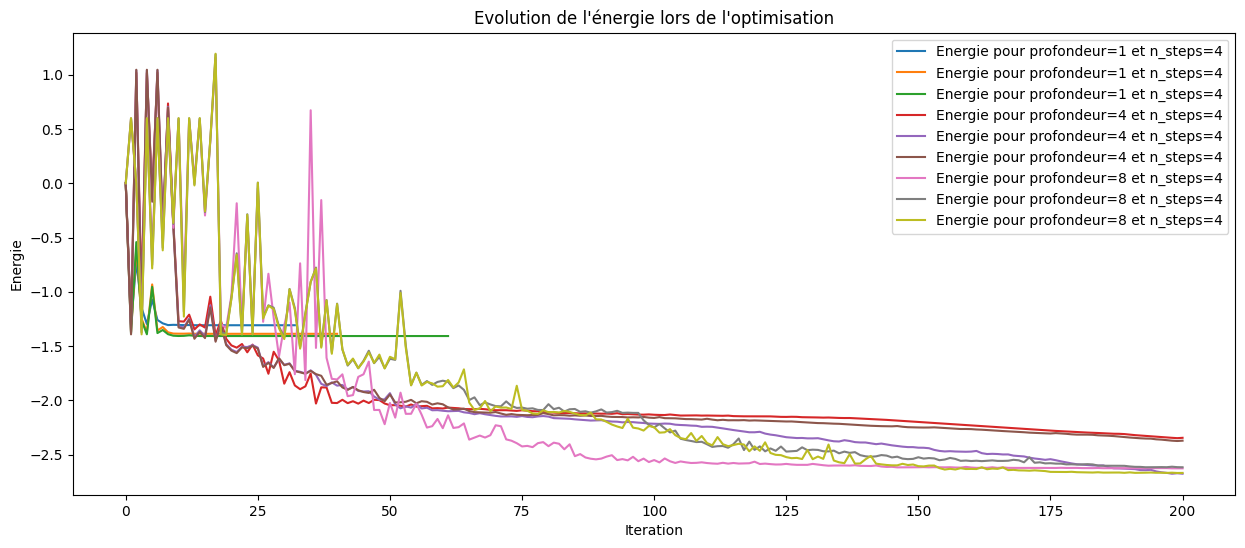

|Psi>
{'0000': (-0.0114311782063935+0.04376500841682148j), '0001': (0.03540396839867181+0.047110584960275995j), '0010': (-0.03563296420710018-0.010547565463294514j), '0011': (0.027227966229325638-0.12528370266928662j), '0100': (-0.1643397629629506-0.04234682620252217j), '0101': (-0.02752440314429695+0.0110497571937232j), '0110': (0.015186356668838942-0.30514076334055773j), '0111': (0.03478589962914381+0.0609919582189434j), '1000': (0.03429247487825688+0.06173749977671371j), '1001': (-0.0702822314657061+0.32737208918833305j), '1010': (-0.027571471652572063+0.011181568654051207j), '1011': (-0.02329655441820052+0.0724241768093601j), '1100': (0.07942469287673916-0.8252942840217429j), '1101': (0.10460761766008955+0.1324165256738839j), '1110': (0.03353852204910455+0.07447783483696939j), '1111': (-0.043664696590476434-0.02153368256904591j)}


In [ ]:
energie_circuit = None
plt.figure(figsize=(15,6))
for depth in [1, 4, 8] :
    for n_trotter_steps in [2, 4, 8] :
        energie_circuit = hva_optimization_loop(psi_0=initial_state, depth=depth, hamiltonians=[H_x], h_target=anderson_U_0,
                           n_steps=n_trotter_steps, init_params=initial_params[:2*depth])
        print("énergie du fondamental estimée sans terme d'interaction", energie_circuit["energie"])
        
plt.show()
non_interacting_psi0 = energie_circuit["circuit"]
non_interacting_psi0.display()
job = non_interacting_psi0.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)



In [137]:
H_xzx = SpinHamiltonian(4, [Term(0.5, "XZXX", [0, 1, 2, 3])])
eigval_xzx, eigvect_xzx = eigh(H_xzx.get_matrix())
print(eigval_xzx[8])
print(eigvect_xzx[:,0])

0.5
[ 0.70710678+0.j  0.        +0.j  0.        +0.j  0.        +0.j
  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
  0.        +0.j  0.        +0.j  0.        +0.j -0.70710678+0.j
  0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]


In [ ]:
initial_state_cluster = QRoutine()

initial_state_cluster.apply(H, 0)
initial_state_cluster.apply(CNOT, [0,2])
initial_state_cluster.apply(I, 3)


initial_state_cluster.display()

job = initial_state_cluster.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)

|Psi>
{'0000': (0.7071067811865475+0j), '1010': (0.7071067811865475+0j)}


In [142]:
H_xzx = SpinHamiltonian(6, [Term(1, "XZZZX", [0, 1, 2, 3, 4]), Term(1, "XZZZX", [1, 2, 3, 4, 5]),
                            Term(1, "YZZZY", [0, 1, 2, 3, 4]), Term(1, "YZZZY", [1, 2, 3, 4, 5])])
eigval_xzx, eigvect_xzx = eigh(H_xzx.get_matrix())
print(eigval_xzx[0])
print(eigvect_xzx[:,0])

-3.999999999999994
[ 0. +0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j -0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]


In [167]:
special_state = QRoutine()

# Our goal is to create: 
# 0.5|000011> + 0.5|010010> + (-0.5)|100001> + 0.5|110000>

# Initialize the control qubits that will create our superposition
special_state.apply(H, 2)  # Control qubit 1
special_state.apply(H, 4)  # Control qubit 2

# Use controlled operations to set the target bits for each state

# State |000011> (3) and |100001> (33)
special_state.apply(CNOT, [2, 0])  # If qubit 2 is |1>, flip qubit 0
special_state.apply(CNOT, [2, 1])  # If qubit 2 is |1>, flip qubit 1

# State |010010> (18) and |110000> (48)
special_state.apply(CNOT, [4, 0])  # If qubit 4 is |1>, flip qubit 0
special_state.apply(CNOT, [4, 3])  # If qubit 4 is |1>, flip qubit 3

# Apply phase to create the negative coefficient for |100001> (33)
special_state.apply(CSIGN, [2, 4])

# Apply RZ rotations to adjust phases and amplitudes
special_state.apply(RZ(np.pi/2), 2)
special_state.apply(RZ(np.pi/2), 4)

job = special_state.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

for key in psi0_dict :
    if np.abs(psi0_dict[key]) < 1e-10 :
        psi0_dict[key] = 0
print(psi0_dict)



|Psi>
{'00000': (8.326672684688674e-17-0.4999999999999999j), '01111': (-8.326672684688674e-17-0.4999999999999999j), '10011': (0.4999999999999999+0j), '11100': (0.4999999999999999+0j)}


In [150]:
print(eigval_xzx[1])

print(eigvect_xzx[:,1])

-3.999999999999994
[ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -0.5+0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]


In [149]:
print(eigval_xzx[2])

print(eigvect_xzx[:,2])

-3.999999999999994
[ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j -0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]


In [152]:
print(eigval_xzx[3])

print(eigvect_xzx[:,3])

-3.999999999999994
[ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -0.5+0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j
  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j]


In [153]:
print(eigval_xzx[4])


-2.0000000000000036


In [161]:
H_xzx = SpinHamiltonian(6, [Term(1, "YZZZYI", [0, 1, 2, 3, 4, 5])])
eigval_xzx, eigvect_xzx = eigh(H_xzx.get_matrix())
print(eigval_xzx[0])
print(eigvect_xzx[:,0])

-0.9999999999999989
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.70710678+0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j]


In [160]:
H_xzx = SpinHamiltonian(6, [Term(1, "IXZZZX", [0,1, 2, 3, 4, 5])])
eigval_xzx, eigvect_xzx = eigh(H_xzx.get_matrix())
print(eigval_xzx[1])
print(eigvect_xzx[:,1])

-0.9999999999999989
[0.        +0.j 0.        +0.j 0.70710678+0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j]


In [154]:
initial_state.apply(RX(-np.pi/2), [0])
initial_state.apply(RX(-np.pi/2), [1])
initial_state.apply(RX(-np.pi/2), [4])
initial_state.apply(RX(-np.pi/2), [5])

# Then apply Rz(pi/2) to qubits 0,1,4,5:
initial_state.apply(RZ(np.pi/2), [0])
initial_state.apply(RZ(np.pi/2), [1])
initial_state.apply(RZ(np.pi/2), [4])
initial_state.apply(RZ(np.pi/2), [5])

# Qubits 2 and 3 remain in |0>, so you can optionally apply the identity:
initial_state.apply(I, 2)
initial_state.apply(I, 3)

job = initial_state.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)

|Psi>
{'000000': (-0.24999999999999983-2.0816681711721685e-16j), '000001': (-1.249000902703301e-16+0.2499999999999999j), '000010': (-8.326672684688674e-17+0.24999999999999992j), '000011': (0.24999999999999997+4.163336342344337e-17j), '000100': (0.24999999999999983+2.0816681711721685e-16j), '000101': (1.249000902703301e-16-0.2499999999999999j), '000110': (8.326672684688674e-17-0.24999999999999992j), '000111': (-0.24999999999999997-4.163336342344337e-17j), '001000': (0.24999999999999983+2.0816681711721685e-16j), '001001': (1.249000902703301e-16-0.2499999999999999j), '001010': (8.326672684688674e-17-0.24999999999999992j), '001011': (-0.24999999999999997-4.163336342344337e-17j), '001100': (-0.24999999999999983-2.0816681711721685e-16j), '001101': (-1.249000902703301e-16+0.2499999999999999j), '001110': (-8.326672684688674e-17+0.24999999999999992j), '001111': (0.24999999999999997+4.163336342344337e-17j)}


énergie du fondamental estimée sans terme d'interaction 2.50000145585183e-09
énergie du fondamental estimée sans terme d'interaction 2.5000027326083085e-09
énergie du fondamental estimée sans terme d'interaction 2.5000045367207235e-09
énergie du fondamental estimée sans terme d'interaction 3.629962080919924e-09
énergie du fondamental estimée sans terme d'interaction 5.814661308001234e-09
énergie du fondamental estimée sans terme d'interaction -1.3343824446621078e-05
énergie du fondamental estimée sans terme d'interaction -0.6973939422611795
énergie du fondamental estimée sans terme d'interaction -0.4374399518089235
énergie du fondamental estimée sans terme d'interaction -0.44548581193562353


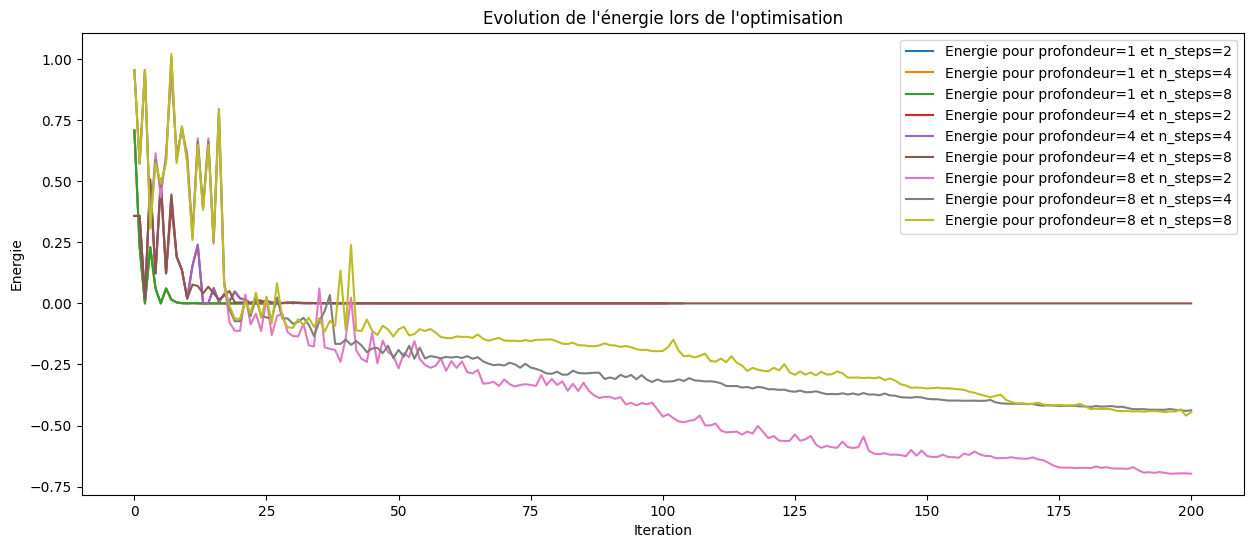

|Psi>
{'0000': (-0.3764916752339308+0.3119571463479461j), '0001': (-0.07909244972983329+0.173922812448391j), '0100': (0.3402381183439927-0.4514198527223421j), '0101': (-0.1255518716602897+0.2609946640709034j), '1010': (-0.3511193293753969+0.07434162776516308j), '1011': (-0.1735395681350338+0.16734163142067252j), '1110': (-0.2738180208664624-0.20966582531442005j), '1111': (0.0898152895728384-0.08411380254583521j)}


In [140]:
energie_circuit = None
plt.figure(figsize=(15,6))
for depth in [1, 4, 8] :
    for n_trotter_steps in [2, 4, 8] :
        energie_circuit = hva_optimization_loop(psi_0=initial_state_cluster, depth=depth, hamiltonians=[H_xzx], h_target=AndersonHamiltonian,
                           n_steps=n_trotter_steps, init_params=initial_params[:2*depth])
        print("énergie du fondamental estimée sans terme d'interaction", energie_circuit["energie"])
        
plt.show()
non_interacting_psi0 = energie_circuit["circuit"]
non_interacting_psi0.display()
job = non_interacting_psi0.to_job()

resultat = get_default_qpu().submit(job)

print("|Psi>")
psi0_dict = {}
for sample in resultat :
    psi0_dict[sample.state.bitstring] = sample.amplitude

print(psi0_dict)

Il faut aussi prendre en compte les termes d'annihilation et de création, puisqu'ils ne sont pas unitaires, on les décompose comme sommes d'unitaire avec la transformation de Jordan-Wigner, on a : 
$$
c_{i,\uparrow} = \frac{1}{2} \left(X_{2i} + i Y_{2i} \right) \prod_{j<2i} Z_j
$$
$$
c_{i,\downarrow} = \frac{1}{2} \left(X_{2i+1} + i Y_{2i+1} \right) \prod_{j<2i+1} Z_j
$$
$$
c_{i,\uparrow}^{\dagger} = \frac{1}{2} \left(X_{2i} - i Y_{2i} \right) \prod_{j<2i} Z_j
$$
$$
c_{i,\downarrow}^{\dagger} = \frac{1}{2} \left(X_{2i+1} - i Y_{2i+1} \right) \prod_{j<2i+1} Z_j
$$

On a aussi $iY = RY(-\pi) = \begin{pmatrix}
0 & 1 \\
-1 & 0
\end{pmatrix}
$ and $-iY = RY(\pi)$

Maintenant on code un circuit correspondant à $c_{j,\sigma}(t)$ and $c_{i, \sigma'}^{\dagger}(0)$ 

In [10]:
def cMapping(index, spin) : 
    '''index commence à 0, repésente soit une impureté (0 <= index<= nb impuretés - 1) soit un mode de bain 5(nb impuretés <= index<= nb qubits - 1'''
    routX = QRoutine()
    routY = QRoutine()
    qubitsActedOn_X = []
    qubitsActedOn_Y = []
    if spin == "+" :
        routX.apply(X, 2*index)
        routY.apply(RY(-np.pi), 2*index) #+iY
        
        for wire in range(2 * index) : 
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index)
        qubitsActedOn_Y.append(2*index)

    else : #spin down
        routX.apply(X, 2*index + 1)
        routY.apply(RY(-np.pi), 2*index + 1)
        for wire in range(2 * index + 1) :
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index + 1)
        qubitsActedOn_Y.append(2*index + 1)
            
    return routX, qubitsActedOn_X, routY, qubitsActedOn_Y
    

In [11]:
def cDagMapping(index, spin) :
    '''index commence à 0, repésente soit une impureté (0 <= index<= nb impuretés - 1) soit un mode de bain 5(nb impuretés <= index<= nb qubits - 1'''
    routX = QRoutine()
    routY = QRoutine()
    qubitsActedOn_X = []
    qubitsActedOn_Y = []
    if spin == "+" :
        routX.apply(X, 2*index)
        routY.apply(RY(np.pi), 2*index) #+iY
        
        for wire in range(2 * index) : 
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index)
        qubitsActedOn_Y.append(2*index)

    else : #spin down
        routX.apply(X, 2*index + 1)
        routY.apply(RY(-np.pi), 2*index + 1)
        for wire in range(2 * index + 1) :
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index + 1)
        qubitsActedOn_Y.append(2*index + 1)
            
    return routX, qubitsActedOn_X, routY, qubitsActedOn_Y

routX, qubitsActedOn_X, routY, qubitsActedOn_Y = cDagMapping(1, "-")
routX.display()
routY.display()


In [12]:
routX, a, routY, b = cMapping(0, "-")
routX_dag, j, routY_dag, j1 = cDagMapping(0,"+")
routX.display()
routY.display()


XYarray (2 element array) ci-dessous se réfère à ce que nous calculons, soit la chaîne de Pauli qui comporte un X ou celle qui comporte un Y pour $c_i$, et la chaîne de Pauli qui comporte un X ou celle qui comporte un Y pour $c_j^{\dagger}$ pour le calcul des matrices unitaires dont la somme nous donne la fonction de Green. Par exemple, si XYarray = ["X", "Y"], nous calculons $e^{i H t} (X_{2i} \prod_{j<2i} Z_j) e^{- i H t}(-iY_{2i} \prod_{j<2i} Z_j)$ (si les deux spins sont vers le haut).

In [13]:
def circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n = h.nbqbits
    rout = QRoutine()
    routX_c, qubitsX, routY_c, qubitsY = cMapping(i, sigma_i)
    routX_cdag, qubitsX_dag, routY_cdag, qubitsY_dag = cDagMapping(j, sigma_j)
    if XYarray[1] == "X" : #optimisation future circuitX_cdag = circuitX_c
        rout.apply(routX_cdag, qubitsX_dag)
    else :
        rout.apply(routY_cdag, qubitsY_dag)
    
    rout.apply(make_trotterisation_routine(h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec -H

    if XYarray[0] == "X" :
        rout.apply(routX_c, qubitsX)
    else :
        rout.apply(routY_c, qubitsY)

    rout.apply(make_trotterisation_routine((-1)*h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec H

    return rout

In [14]:
Hx = SpinHamiltonian(1, [Term(1, "X", [0])])

In [15]:
circuitGreen(0, "+", 0, "+", Hx, t=3, N=1, XYarray=["X","X"]).display()

In [16]:
def circuitGreenProba(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    proba = {}
    job = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job()
    qpu = get_default_qpu()
    result = qpu.submit(job)

    for sample in result :
        proba[sample.state.bitstring] = sample.probability
    
    return proba

circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, 1, 1, ["X", "X"])


{'0000': 0.29192658172642827, '1010': 0.7080734182735693}

Calcul de l'opérateur de corrélation pour $H_{test} = H$ pour des temps $t \in [0, 10]$

In [17]:
sigmaX = np.array([
        [0, 1],
        [1, 0]
    ])
ket1 = np.array([
    [0], 
    [1]
    ])

def calculThéorique(t) :
    expiHt = np.array([
        [np.cos(t) + 1j * np.sin(t)/np.sqrt(2) ,        1j*np.sin(t)/np.sqrt(2)     ],
        [1j * np.sin(t)/np.sqrt(2)             , np.cos(t) - 1j*np.sin(t)/np.sqrt(2)]
    ])
    exp_iHt = np.conj(expiHt)
    
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2

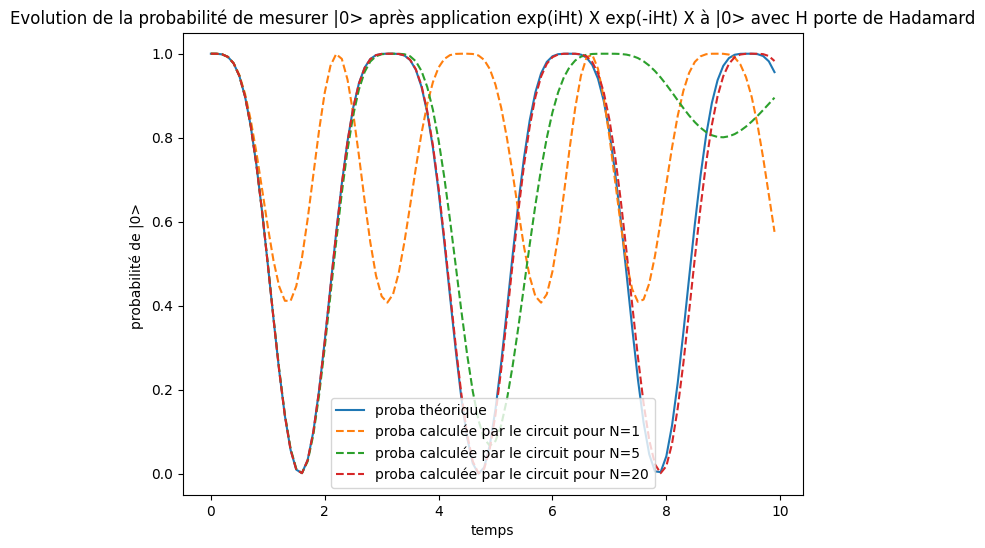

In [18]:
T = np.arange(0, 10, 0.1)
resultatTheorique = [calculThéorique(t) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheorique, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    resultatCirc = [circuitGreenProba(0, "+", 0, "+", H_test, t, N=N_steps, XYarray=["X","X"])["0"] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |0> après application exp(iHt) X exp(-iHt) X à |0> avec H porte de Hadamard")
plt.legend()
plt.show()
    


Calcul de l'opérateur de corrélation pour $H_{test2} = \begin{pmatrix} 5 & 2 - 3i \\ 2 + 3i & -3 \end{pmatrix}
$ pour des temps $t \in [0, 1000]$


In [19]:
H_test2= SpinHamiltonian(1, [Term(1, "I", [0]), Term(2, "X", [0]),
                             Term(3, "Y", [0]), Term(4, "Z", [0])])
print(H_test2)


1.0 * I^1 +
2 * (X|[0]) +
3 * (Y|[0]) +
4 * (Z|[0])


In [22]:
def calculThéorique2(t) :
    iHt = 1j * t * np.array([
        [   5   , 2 - 3j ],
        [2 + 3j ,   -3   ]
        ])
    expiHt = expm(iHt)
    exp_iHt = expm(- iHt)
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2


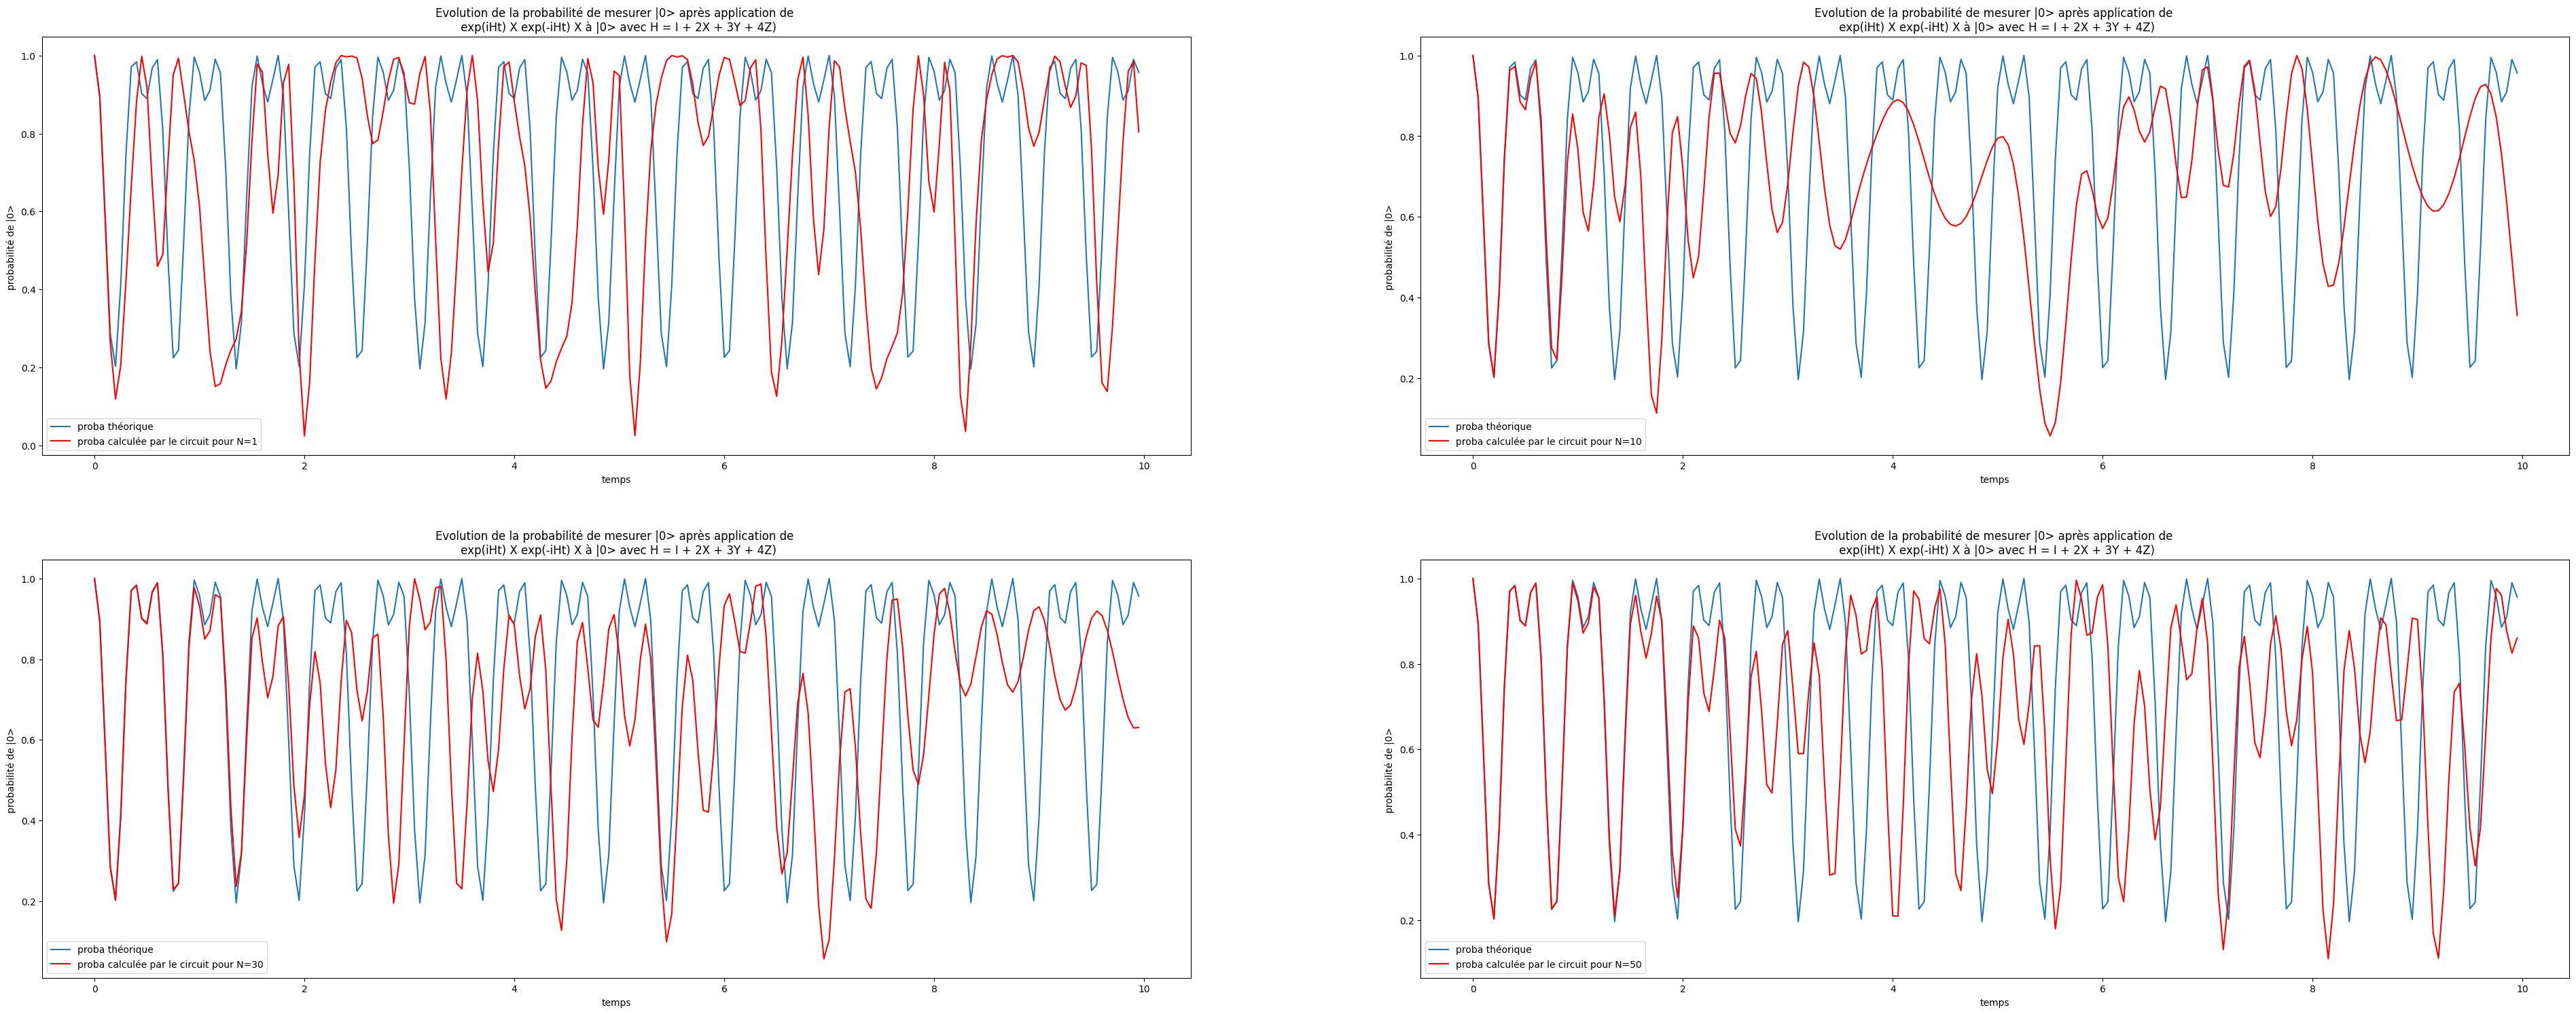

In [23]:
T = np.arange(0, 10, 0.05)
resultatTheorique = np.ravel(np.array([calculThéorique2(t) for t in T]))
fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(48, 18))

for ax, n_steps in [(ax1, 1), (ax2, 10), (ax3, 30), (ax4, 50)] :
    ax.plot(T, resultatTheorique, label = 'proba théorique')
    resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", H_test2, t, N=n_steps, XYarray=["X","X"])["0"] for t in T])
    ax.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={n_steps}', color="r" )

    ax.set_xlabel('temps')
    ax.set_ylabel('probabilité de |0> ')
    ax.set_title("Evolution de la probabilité de mesurer |0> après application de \n exp(iHt) X exp(-iHt) X à |0> avec H = I + 2X + 3Y + 4Z)")
    ax.legend()

plt.subplots_adjust(hspace=0.25)
plt.show()
    

Calcul de l'opérateur de corrélation pour $H_{test3} = \begin{pmatrix} cos(\theta) & -i sin(\theta) \\ i sin(\theta) & cos(\theta) \end{pmatrix}
$ pour des temps $t \in [0, 100]$


In [24]:
def H_test3(theta) :
    return SpinHamiltonian(1, [Term(np.cos(theta), "I", [0]), Term(np.sin(theta), "Y", [0])])

print(H_test3(np.pi / 3))

0.5000000000000001 * I^1 +
0.8660254037844386 * (Y|[0])


In [20]:
def calculThéorique3(t, theta) :
    iHt = 1j * t * np.array([
        [np.cos(theta), -1j * np.sin(theta)], 
        [1j * np.sin(theta), np.cos(theta)]])
    expiHt = expm(iHt)
    exp_iHt = expm(- iHt)
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2


In [21]:
angle = { np.pi/3 : "π/3", np.pi/4 : "π/4", np.pi/6 : "π/6", np.pi/12 : "π/12"}

différence maximale : 2.8310687127941492e-14
différence maximale : 2.708944180085382e-14
différence maximale : 2.886579864025407e-14
différence maximale : 1.8096635301390052e-14
différence maximale : 1.9012569296705806e-14
différence maximale : 2.0761170560490427e-14
différence maximale : 2.6978419498391304e-14
différence maximale : 3.108624468950438e-14
différence maximale : 3.3084646133829665e-14
différence maximale : 2.220446049250313e-14
différence maximale : 2.1538326677728037e-14
différence maximale : 2.0317081350640365e-14


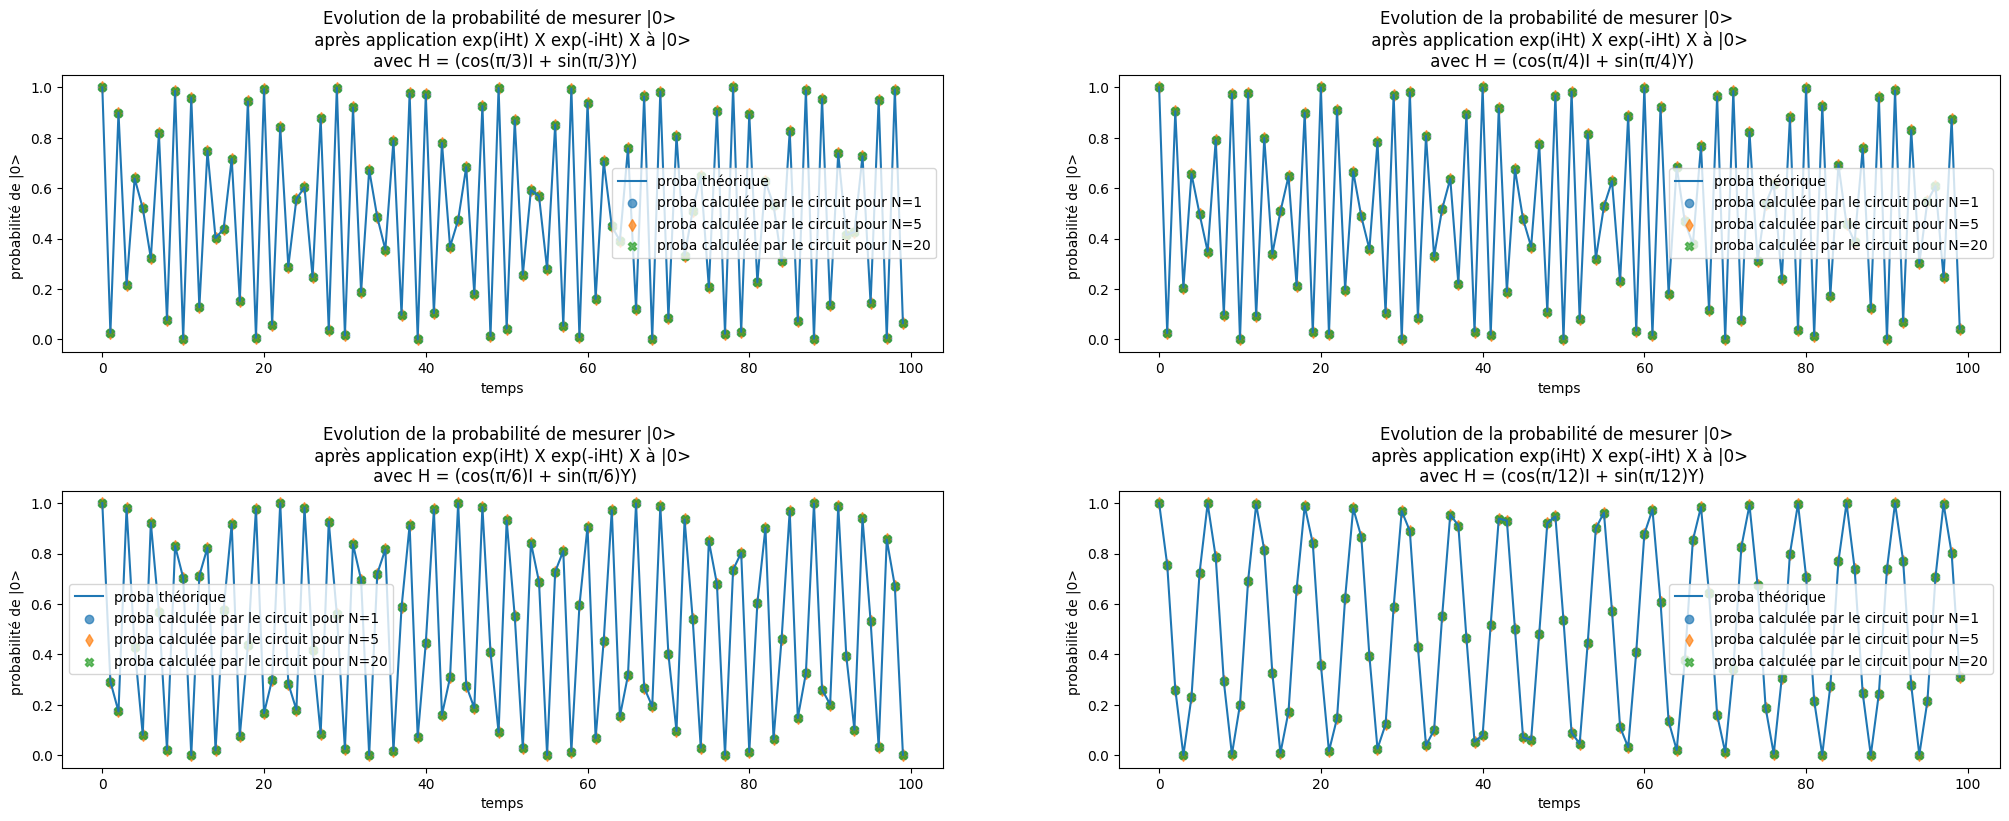

In [27]:
T = np.arange(0, 100, 1)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(25, 9))

for ax, theta in [(ax1, np.pi/3), (ax2, np.pi/4), (ax3, np.pi/6), (ax4, np.pi/12)] :
    resultatTheorique = np.ravel(np.array([calculThéorique3(t, theta) for t in T]))
    ax.plot(T, resultatTheorique, label = 'proba théorique')
    for n_steps, style in [(1, "o"), (5, 'd'), (20, 'X')] :
        
        resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", H_test3(theta), t, N=n_steps, XYarray=["X","X"])["0"] for t in T])
        print("différence maximale :", np.max(np.abs(resultatCirc - resultatTheorique)))
        ax.scatter(T, resultatCirc, alpha = 0.7, label = f'proba calculée par le circuit pour N={n_steps}', marker=style)
        ax.set_xlabel('temps')
        ax.set_ylabel('probabilité de |0> ')
        ax.set_title(f"Evolution de la probabilité de mesurer |0> \n après application exp(iHt) X exp(-iHt) X à |0> \n avec H = (cos({angle[theta]})I + sin({angle[theta]})Y)")
        ax.legend()

plt.subplots_adjust(hspace=0.5)
plt.show()

concordance quasi-parfaite mais résultat pas étonnant car I et Y commutent donc la trotterization est une égalité

Calcul de l'opérateur de corrélation pour $H_{test4} = \begin{pmatrix} cos(\theta) & sin(\theta) \\ sin(\theta) & cos(\theta) \end{pmatrix}
$ pour des temps $t \in [0, 100]$


In [28]:
def H_test4(theta) :
    return SpinHamiltonian(1, [Term(np.cos(theta), "I", [0]), Term(np.sin(theta), "X", [0])])

print(H_test4(np.pi / 3))

0.5000000000000001 * I^1 +
0.8660254037844386 * (X|[0])


In [29]:
def calculThéorique4(t, theta) :
    iHt = 1j * t * np.array([
        [np.cos(theta), np.sin(theta)], 
        [ np.sin(theta), np.cos(theta)]])
    expiHt = expm(iHt)
    exp_iHt = expm(- iHt)
    return np.absolute((expiHt @ sigmaX @ exp_iHt @ ket1)[0])**2


différence maximale : 3.597122599785507e-14
différence maximale : 5.218048215738236e-14
différence maximale : 2.19824158875781e-14
différence maximale : 3.4638958368304884e-14
différence maximale : 3.730349362740526e-14
différence maximale : 3.7969627442180354e-14
différence maximale : 2.6201263381153694e-14
différence maximale : 3.752553823233029e-14


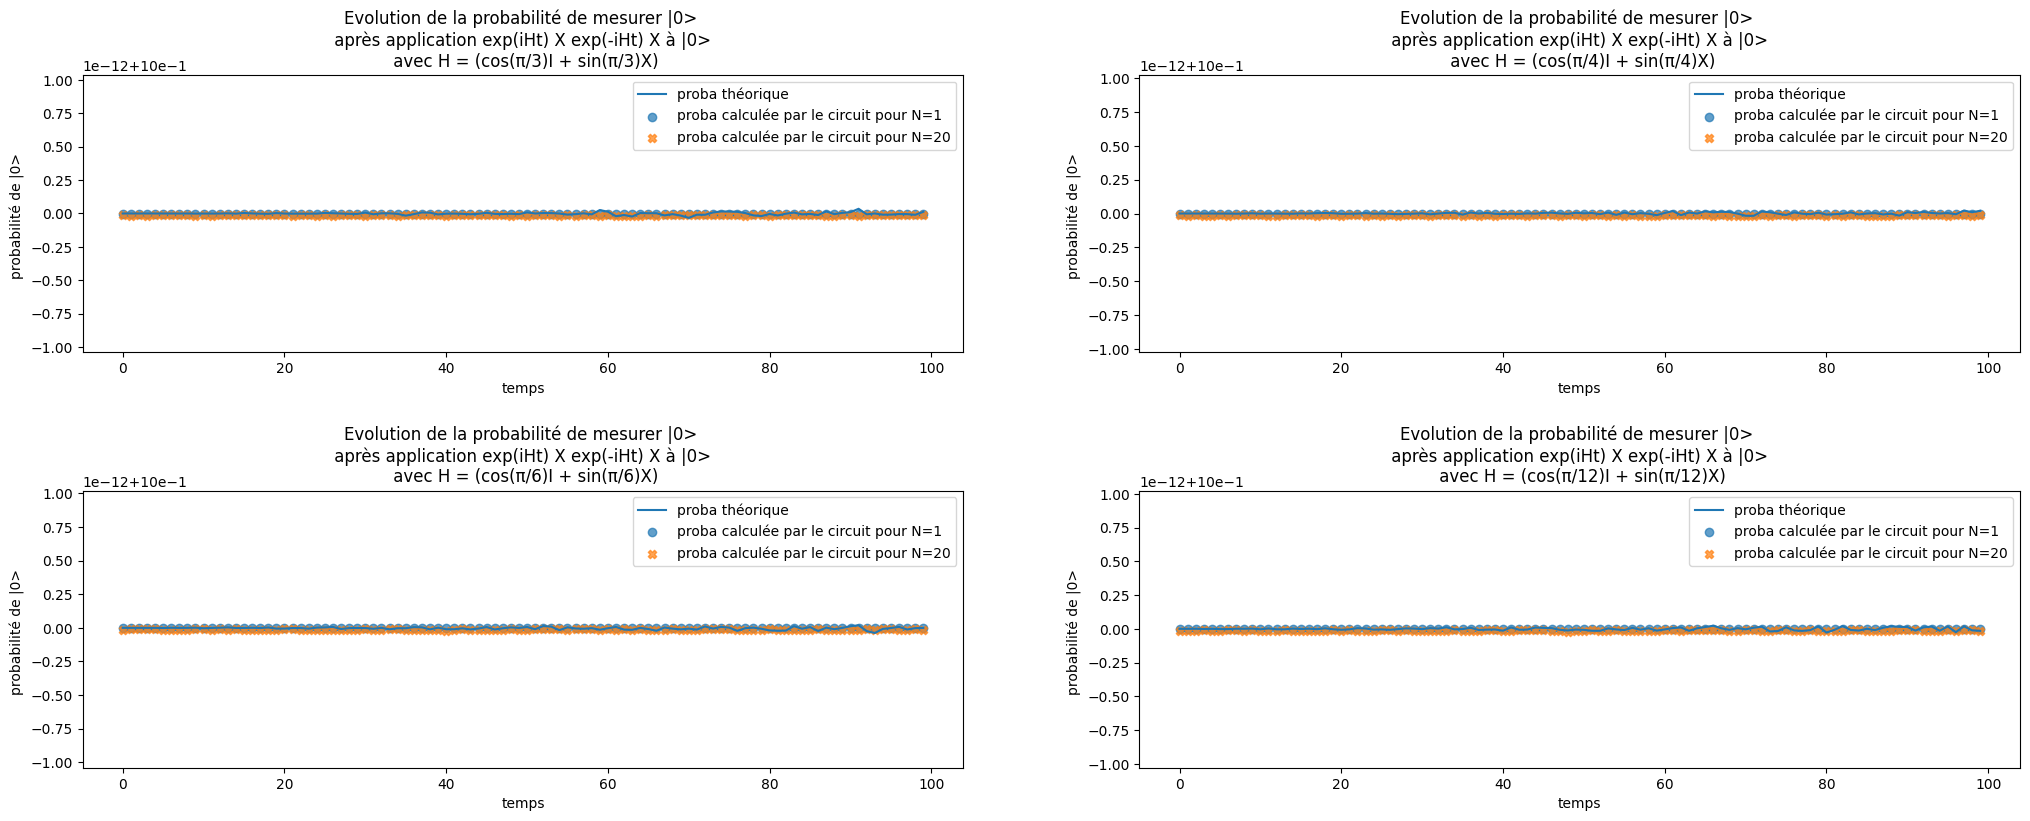

In [30]:
T = np.arange(0, 100, 1)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(25, 9))

for ax, theta in [(ax1, np.pi/3), (ax2, np.pi/4), (ax3, np.pi/6), (ax4, np.pi/12)] :
    resultatTheorique = np.ravel(np.array([calculThéorique4(t, theta) for t in T]))
    ax.plot(T, resultatTheorique, label = 'proba théorique')
    for n_steps, style in [(1, "o"), (20, 'X')] :
        
        resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", H_test4(theta), t, N=n_steps, XYarray=["X","X"])["0"] for t in T])
        print("différence maximale :", np.max(np.abs(resultatCirc - resultatTheorique)))
        ax.scatter(T, resultatCirc, alpha = 0.7, label = f'proba calculée par le circuit pour N={n_steps}', marker=style)
        ax.set_xlabel('temps')
        ax.set_ylabel('probabilité de |0> ')
        ax.set_title(f"Evolution de la probabilité de mesurer |0> \n après application exp(iHt) X exp(-iHt) X à |0> \n avec H = (cos({angle[theta]})I + sin({angle[theta]})X)")
        ax.legend()

plt.subplots_adjust(hspace=0.5)
plt.show()

In [31]:
AndersonHamiltonian, matrix = hamiltonian(1, 1, 1, 1, 0, [[1]], [1])

In [22]:

ket_0 = np.zeros((16,1))
ket_0[0] = 1

otherQubits = np.eye(8)
def calculTheoriqueAnderson(t, state) :
    I = np.eye(2)
    sigmaXIII = np.kron(np.kron(np.kron(sigmaX, I), I), I)
    iHt = 1j * t * matrix
    expiHt = expm(iHt)
    exp_iHt = expm(-iHt)
    ket_1 = sigmaXIII @ ket_0
    
    return np.absolute((expiHt @ sigmaXIII @ exp_iHt @ ket_1)[state])**2

for state in range(16) :
    print(calculTheoriqueAnderson(1, state))

[0.51215922]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.48784078]
[0.]
[0.]
[0.]
[0.]
[0.]


In [33]:
'''T = np.arange(0, 10, 0.1)
resultatTheoriqueA = [calculTheoriqueAnderson(t, 0) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheoriqueA, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    resultatCirc = [circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])["0000"] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |0000> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l'hamiltonien d'Anderson")
plt.legend()
plt.show()'''

'T = np.arange(0, 10, 0.1)\nresultatTheoriqueA = [calculTheoriqueAnderson(t, 0) for t in T]\nplt.figure(figsize=(8,6))\nplt.plot(T, resultatTheoriqueA, label = \'proba théorique\')\n\nfor N_steps in [1, 5, 20] :\n    resultatCirc = [circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])["0000"] for t in T]\n    plt.plot(T, resultatCirc, label = f\'proba calculée par le circuit pour N={N_steps}\', linestyle=\'--\')\n\nplt.xlabel(\'temps\')\nplt.ylabel(\'probabilité de |0> \')\nplt.title("Evolution de la probabilité de mesurer |0000> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l\'hamiltonien d\'Anderson")\nplt.legend()\nplt.show()'

In [23]:
print(circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, 9.9, N=N_steps, XYarray=["X","X"]))

{'0000': 0.5364217758448608, '1010': 0.4635782241550905}


In [35]:
'''T = np.arange(0.1, 10, 0.1)
resultatTheoriqueA = [calculTheoriqueAnderson(t, 10) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheoriqueA, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    
    resultatCirc = [circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |1010> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l'hamiltonien d'Anderson")
plt.legend()
plt.show()'''

'T = np.arange(0.1, 10, 0.1)\nresultatTheoriqueA = [calculTheoriqueAnderson(t, 10) for t in T]\nplt.figure(figsize=(8,6))\nplt.plot(T, resultatTheoriqueA, label = \'proba théorique\')\n\nfor N_steps in [1, 5, 20] :\n    \n    resultatCirc = [circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])[\'1010\'] for t in T]\n    plt.plot(T, resultatCirc, label = f\'proba calculée par le circuit pour N={N_steps}\', linestyle=\'--\')\n\nplt.xlabel(\'temps\')\nplt.ylabel(\'probabilité de |0> \')\nplt.title("Evolution de la probabilité de mesurer |1010> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l\'hamiltonien d\'Anderson")\nplt.legend()\nplt.show()'

In [ ]:
'''
for N_steps in [1, 5, 20] :
    resultatCirc = [circuitGreenProba(0, "+", 1, "-", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])["0011"] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('Temps')
plt.ylabel('Probabilité')
plt.title("Evolution de la probabilité de mesurer |0011> après application de \n exp(iHt) X exp(-iHt) ZZZX à |0000> avec H l'hamiltonien d'Anderson")
plt.legend()
plt.show()'''

KeyError: '0011'

Defining a noisy quantum computer model :

In [ ]:
'''eps1 = 0.01
eps2 = 0.1
hw_model = make_depolarizing_hardware_model(eps1=eps1, eps2=eps2, depol_type="randomizing", correl_type="multi_qubit")
noisy_qpu = get_default_qpu(hardware_model=hw_model, sim_method="deterministic-vectorized")'''

'eps1 = 0.01\neps2 = 0.1\nhw_model = make_depolarizing_hardware_model(eps1=eps1, eps2=eps2, depol_type="randomizing", correl_type="multi_qubit")\nnoisy_qpu = get_default_qpu(hardware_model=hw_model, sim_method="deterministic-vectorized")'

In [ ]:
'''def circuitGreenProbaNoisy(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    proba = {}
    job = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job()
    qpu = noisy_qpu()
    result = qpu.submit(job)

    for sample in result :
        proba[sample.state.bitstring] = sample.probability
    
    return proba'''

'def circuitGreenProbaNoisy(i, sigma_i, j, sigma_j, h, t, N, XYarray) :\n    proba = {}\n    job = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job()\n    qpu = noisy_qpu()\n    result = qpu.submit(job)\n\n    for sample in result :\n        proba[sample.state.bitstring] = sample.probability\n    \n    return proba'

In [ ]:
'''T = np.arange(0.1, 10, 0.1)
resultatTheoriqueA = [calculTheoriqueAnderson(t, 10) for t in T]
plt.figure(figsize=(8,6))
plt.plot(T, resultatTheoriqueA, label = 'proba théorique')

for N_steps in [1, 5, 20] :
    
    resultatCirc = [circuitGreenProbaNoisy(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T]
    plt.plot(T, resultatCirc, label = f'proba calculée par le circuit pour N={N_steps}', linestyle='--')

plt.xlabel('temps')
plt.ylabel('probabilité de |0> ')
plt.title("Evolution de la probabilité de mesurer |1010> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l'hamiltonien d'Anderson")
plt.legend()
plt.show()'''

'T = np.arange(0.1, 10, 0.1)\nresultatTheoriqueA = [calculTheoriqueAnderson(t, 10) for t in T]\nplt.figure(figsize=(8,6))\nplt.plot(T, resultatTheoriqueA, label = \'proba théorique\')\n\nfor N_steps in [1, 5, 20] :\n    \n    resultatCirc = [circuitGreenProbaNoisy(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])[\'1010\'] for t in T]\n    plt.plot(T, resultatCirc, label = f\'proba calculée par le circuit pour N={N_steps}\', linestyle=\'--\')\n\nplt.xlabel(\'temps\')\nplt.ylabel(\'probabilité de |0> \')\nplt.title("Evolution de la probabilité de mesurer |1010> après application de \n exp(iHt) X exp(-iHt) X à |0000> avec H l\'hamiltonien d\'Anderson")\nplt.legend()\nplt.show()'

In [ ]:
''''T = np.arange(0.1, 25, 0.1)
resultatTheoriqueA = np.array([calculTheoriqueAnderson(t, 10) for t in T])
plt.figure(figsize=(8,6))
l2_distance = []
l2_distance_noise = []
NumberOfSteps = np.array([1, 5, 10, 20, 35, 50])


for N_steps in NumberOfSteps :
    
    resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T])
    #resultatCircNoise = np.array([circuitGreenProbaNoisy(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T])

    l2_distance.append(np.linalg.norm(resultatTheoriqueA - resultatCirc))
    #l2_distance_noise.append(np.linalg.norm(resultatTheoriqueA - resultatCircNoise))'''
   
''''plt.scatter(NumberOfSteps, l2_distance, label = f'Erreur de la trotterization en norme L2', color="b")
plt.plot(NumberOfSteps, l2_distance, linestyle='--', color="b")
#plt.scatter(NumberOfSteps, l2_distance_noise, label = f'Erreur de la trotterization en norme L2', color="r")
#plt.plot(NumberOfSteps, l2_distance_noise, linestyle='--', color="r")

plt.xlabel("Nombre d'étapes")
plt.ylabel('Erreur')
plt.title("Evolution de la l'erreur L2 liée à la trotterization, pour \n la mesure de la probabilité de |1010>, avec l'hamiltonien d'Anderson")
plt.legend()
plt.show()'''

'\'plt.scatter(NumberOfSteps, l2_distance, label = f\'Erreur de la trotterization en norme L2\', color="b")\nplt.plot(NumberOfSteps, l2_distance, linestyle=\'--\', color="b")\n#plt.scatter(NumberOfSteps, l2_distance_noise, label = f\'Erreur de la trotterization en norme L2\', color="r")\n#plt.plot(NumberOfSteps, l2_distance_noise, linestyle=\'--\', color="r")\n\nplt.xlabel("Nombre d\'étapes")\nplt.ylabel(\'Erreur\')\nplt.title("Evolution de la l\'erreur L2 liée à la trotterization, pour \n la mesure de la probabilité de |1010>, avec l\'hamiltonien d\'Anderson")\nplt.legend()\nplt.show()'

In [ ]:
'''T = np.arange(0.1, 20, 0.1)
resultatTheoriqueA = np.array([calculTheoriqueAnderson(t, 10) for t in T])
plt.figure(figsize=(8,6))

max_distance = []
max_distance_noise = []
NumberOfSteps = np.array([1, 5, 10, 20, 35, 50])

for N_steps in NumberOfSteps :
    
    resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T])
    resultatCircNoise = np.array([circuitGreenProbaNoisy(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])['1010'] for t in T])
    max_distance.append(np.max(np.abs(resultatTheoriqueA - resultatCirc)))
    max_distance_noise.append(np.max(np.abs(resultatTheoriqueA - resultatCircNoise)))

plt.scatter(NumberOfSteps, max_distance, label='Erreur de la trotterization en norme L∞ avec un ordinateur quantique idéal', color="b")
plt.scatter(NumberOfSteps, max_distance_noise, label='Erreur de la trotterization en norme L∞ avec du bruit', color="r")
plt.plot(NumberOfSteps, max_distance, linestyle='--', color="b")
plt.plot(NumberOfSteps, max_distance_noise, linestyle='--', color="r")

plt.xlabel("Nombre d'étapes")
plt.ylabel('Erreur')
plt.title("Evolution de la l'erreur en norme infinie liée à la trotterization pour \n la mesure de la probabilité de |1010>, avec l'hamiltonien d'Anderson")
plt.legend()
plt.show()'''

'T = np.arange(0.1, 20, 0.1)\nresultatTheoriqueA = np.array([calculTheoriqueAnderson(t, 10) for t in T])\nplt.figure(figsize=(8,6))\n\nmax_distance = []\nmax_distance_noise = []\nNumberOfSteps = np.array([1, 5, 10, 20, 35, 50])\n\nfor N_steps in NumberOfSteps :\n    \n    resultatCirc = np.array([circuitGreenProba(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])[\'1010\'] for t in T])\n    resultatCircNoise = np.array([circuitGreenProbaNoisy(0, "+", 0, "+", AndersonHamiltonian, t, N=N_steps, XYarray=["X","X"])[\'1010\'] for t in T])\n    max_distance.append(np.max(np.abs(resultatTheoriqueA - resultatCirc)))\n    max_distance_noise.append(np.max(np.abs(resultatTheoriqueA - resultatCircNoise)))\n\nplt.scatter(NumberOfSteps, max_distance, label=\'Erreur de la trotterization en norme L∞ avec un ordinateur quantique idéal\', color="b")\nplt.scatter(NumberOfSteps, max_distance_noise, label=\'Erreur de la trotterization en norme L∞ avec du bruit\', color="r")\nplt.plot(Nu

On peut essayer de calculer la fonction de Green autrement en utilisant le fait qu'elle s'applique à l'état fondamental

Il reste à calculer la moyenne $\exp{(iHt)} c_{j,\sigma} \exp{(-iHt)} c_{i, \sigma'}^{\dagger} \ket{\psi_{0}}$ and $\ket{\psi_{0}}$ avec un test de Hadamard. Pour cela on construit une porte controle U où U est la fonction entre le bra et le ket dans la fonction de Green :

In [24]:
def realHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()
    routineH.apply(psi_0, [range(1, psi_0.arity + 1)])
    routineH.apply(H, 0)
    correlator = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)

    return routineH

def imHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()

    routineH.apply(H, 0)
    routineH.apply(S.dag(), 0)

    routineH.apply(psi_0, [range(1,psi_0.arity + 1)])

    correlator = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)
    return routineH

imHTest(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1, ["X","X"]).display()

In [25]:
def circuitGreenTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    amplitudes = {}
    rout = QRoutine()
    rout.apply(psi_0, [range(psi_0.arity)])
    rout.apply(circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray), [range(h.nbqbits)])
    qpu = get_default_qpu()
    job = rout.to_job()
    result = qpu.submit(job)

    for sample in result :
        amplitudes[sample.state] = sample.amplitude
    
    return amplitudes
for XYarray in [['X','X'],['X','Y'],['Y','X'],['Y','Y']] :
    print(circuitGreenTest(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1, XYarray))
print(psi0_dict)

{|0000>: (0.04151601111786086+0.04275803149621917j), |0001>: (-0.03771938665210778+0.014228484152647318j), |0010>: (0.10036371351017764+0.037986452967537554j), |0011>: (0.43731794882444663+0.00652049192762813j), |0100>: (0.007896954650783328+0.04414796161922722j), |0101>: (0.056973350797829905-0.07190687524664502j), |0110>: (0.5216490207659763-0.38307960422801146j), |0111>: (-0.10126910560857899-0.029604608469390472j), |1000>: (0.10012231842315275+0.005025693902473982j), |1001>: (0.21351342446151936-0.14217658770774735j), |1010>: (0.054750993729341606+0.04484973601767554j), |1011>: (-0.016419761097242132+0.04071367027140311j), |1100>: (-0.49852835447368476+0.009659543085703493j), |1101>: (0.09049683166187275+0.06701152024549364j), |1110>: (0.01897630822602111+0.018192585395618438j), |1111>: (0.058956848481101984-0.05771303362452947j)}
{|0000>: (0.037134863938022095+0.07900919514860835j), |0001>: (-0.02118560429584439+0.03083680539758789j), |0010>: (-0.03731139064638416+0.06115218973902

In [26]:
def testG_t(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    qpu = get_default_qpu()
    GreenFunc = 0
    
    job = psi_0.to_job()
    resultat0 = qpu.submit(job)
    
    for XYarray in arrays :
        for sample in resultat0 :  
        
            circ = circuitGreenTest(psi_0, i, sigma_i , j , sigma_j , h, t, N, XYarray) #dictionnaire d'amplitudes
            for etat in circ :

                if sample.state.bitstring == etat.bitstring :
                    GreenFunc += (1/4) * ((np.real(sample.amplitude)*np.real(circ[etat]) + np.imag(sample.amplitude)*np.imag(circ[etat])) +\
                                          1j * (np.real(sample.amplitude)*np.imag(circ[etat]) + np.imag(-sample.amplitude)*np.real(circ[etat])))
                
    return -1j * GreenFunc



In [27]:
def G_t_CCDag(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    
    GreenFunction = 0
    n_qubits = h.nbqbits    
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    for XYarray in arrays :
        obs = Observable(n_qubits + 1, pauli_terms=[Term(1, "Z", [0])])

        qpu = get_default_qpu()
        
        job_ReHtest = realHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ReHtest = qpu.submit(job_ReHtest)

        job_ImHtest = imHTest(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ImHtest = qpu.submit(job_ImHtest)
        
        GreenFunction += 1/4 * (result_ReHtest.value + 1j * result_ImHtest.value)

    return -1j * GreenFunction


print(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1))


(-0.18454293112977505+0.13517873110591458j)


In [28]:
print("Test", testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 5, 1))
print()

print("Test",testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 100 , 1))
print("Fonction calculée avec circuit :", G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 100, 1))
print()

print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t_CCDag(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t_CCDag(psi0, 1, "+", 0, "+", AndersonHamiltonian, 5, 1))



Test (-0.1845429311297754+0.13517873110591455j)
Fonction calculée avec circuit : (-0.18454293112977505+0.13517873110591458j)

Test (0.12981134534904218+0.21302444920734578j)
Fonction calculée avec circuit : (0.1298113453490417+0.2130244492073455j)

Test (0.14671217807744508-0.10311111446485119j)
Fonction calculée avec circuit : (0.14671217807744497-0.10311111446485091j)

Test (-0.28114814719926756-0.03522802810473054j)
Fonction calculée avec circuit : (-0.2811481471992674-0.03522802810473038j)

Test (0.11686732146542582+0.13101253956416917j)
Fonction calculée avec circuit : (0.11686732146542553+0.13101253956416892j)


In [29]:
print("Test", np.abs(testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 1 , 1)))
print("Fonction calculée avec circuit :", np.abs(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1)))
print()
print("Test",np.abs(testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 5 , 1)))
print("Fonction calculée avec circuit :", np.abs(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 5, 1)))
print()
print("Test",np.abs(testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 20 , 1)))
print("Fonction calculée avec circuit :", np.abs(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 20, 1)))
print()
print("Test", np.abs(testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 100 , 1)))
print("Fonction calculée avec circuit :", np.abs(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 100, 1)))
print()
print("Test", np.abs(testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 200 , 3)))
print("Fonction calculée avec circuit :", np.abs(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 200, 3)))

print("Test", np.abs(testG_t(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 500 , 3)))
print("Fonction calculée avec circuit :", np.abs(G_t_CCDag(psi0, 0, "+", 0, "+", AndersonHamiltonian, 500, 3)))
'''print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t(psi0, 1, "+", 0, "+", AndersonHamiltonian, 5, 1))'''



Test 0.22875616444890437
Fonction calculée avec circuit : 0.2287561644489041

Test 0.24946021995785486
Fonction calculée avec circuit : 0.24946021995785442

Test 0.26500161645919273
Fonction calculée avec circuit : 0.2650016164591925

Test 0.17932195939820533
Fonction calculée avec circuit : 0.17932195939820508

Test 0.21739292200498792
Fonction calculée avec circuit : 0.2173929220049878
Test 0.09585459791990603
Fonction calculée avec circuit : 0.09585459791990615


'print("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 1 , 1))\nprint("Fonction calculée avec circuit :", G_t(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1))\nprint()\nprint("Test",testG_t(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 5 , 1))\nprint("Fonction calculée avec circuit :", G_t(psi0, 1, "+", 0, "+", AndersonHamiltonian, 5, 1))'

<h2>Pour calculer la fonction spectrale, il faut calculer la fonction de Green retardée :</h2> 


$\langle \{ c_\alpha(t), c^\dagger_{\alpha'}(t') \} \rangle$, donc il faut faire la même démarche mais cette fois-ci avec $c^\dagger_{j, \sigma} e^{i H t} c_{i, \sigma'} e^{-i H t}$

In [30]:
def circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n = h.nbqbits
    rout = QRoutine()
    routX_c, qubitsX, routY_c, qubitsY = cMapping(i, sigma_i)
    routX_cdag, qubitsX_dag, routY_cdag, qubitsY_dag = cDagMapping(j, sigma_j)
    
    rout.apply(make_trotterisation_routine(h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec -H
    
    if XYarray[0] == "X" :
        rout.apply(routX_c, qubitsX)
    else :
        rout.apply(routY_c, qubitsY)
    
    rout.apply(make_trotterisation_routine((-1)*h, n_trotter_steps=N, final_time=t), [range(n)]) #Trotterization avec H

    if XYarray[1] == "X" : #optimisation future circuitX_cdag = circuitX_c
        rout.apply(routX_cdag, qubitsX_dag)
    else :
        rout.apply(routY_cdag, qubitsY_dag)

    return rout


In [31]:
def realHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()
    routineH.apply(psi_0, [range(1, psi_0.arity + 1)])
    routineH.apply(H, 0)
    correlator = circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)

    return routineH

def imHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    n_qubits = h.nbqbits
    routineH = QRoutine()

    routineH.apply(H, 0)
    routineH.apply(S.dag(), 0)

    routineH.apply(psi_0, [range(1,psi_0.arity + 1)])

    correlator = circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    
    routineH.apply(correlator.ctrl(), [range(n_qubits + 1)])
    routineH.apply(H, 0)
    return routineH


In [32]:
def G_t_CDagC(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    GreenFunction = 0
    n_qubits = h.nbqbits    
    arrays = [['X','X'],['X','Y'],['Y','X'], ['Y','Y']]
    for XYarray in arrays :
        obs = Observable(n_qubits + 1, pauli_terms=[Term(1, "Z", [0])])

        qpu = get_default_qpu()
        
        job_ReHtest = realHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ReHtest = qpu.submit(job_ReHtest)
        
        job_ImHtest = imHTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray).to_job(observable=obs)
        result_ImHtest = qpu.submit(job_ImHtest)
        GreenFunction += 1/4 * (result_ReHtest.value + 1j * result_ImHtest.value)

    return -1j * GreenFunction

In [33]:
def circuitGreenTest_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    
    amplitudes = {}
    rout = QRoutine()
    rout.apply(psi_0, [range(psi_0.arity)])
    rout.apply(circuitGreen_CDagC(i, sigma_i, j, sigma_j, h, t, N, XYarray), [range(h.nbqbits)])
    qpu = get_default_qpu()
    job = rout.to_job()
    result = qpu.submit(job)

    for sample in result :
        amplitudes[sample.state] = sample.amplitude
    
    return amplitudes
for XYarray in [['X','X'],['X','Y'],['Y','X'],['Y','Y']] :
    print(circuitGreenTest_CDagC(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1, XYarray))
print(psi0_dict)

{|0000>: (-0.04151601111786084-0.042758031496219165j), |0001>: (0.028499878484125222+0.0018844632688203317j), |0010>: (-0.10036371351017762-0.03798645296753769j), |0011>: (-0.5067259774536534-0.20063744154884183j), |0100>: (-0.006531070721058446-0.015652902203466476j), |0101>: (-0.05799397402356067+0.04197215959325335j), |0110>: (-0.28971466504853066+0.15269631461348382j), |0111>: (0.0770161078628725+0.03888795515806745j), |1000>: (-0.10012231842315297-0.005025693902474183j), |1001>: (-0.21687170883994253+0.006299655325557346j), |1010>: (-0.054750993729341536-0.04484973601767549j), |1011>: (-0.01120173737395479-0.05519276815784933j), |1100>: (0.14773775387441573-0.6718678160429903j), |1101>: (-0.1169635313157795+0.05184460815994392j), |1110>: (-0.04334740777330952+0.010035307267071891j), |1111>: (0.027645842056057558+0.09661267957614765j)}
{|0000>: (0.04151601111786083+0.042758031496219165j), |0001>: (-0.028499878484125236-0.0018844632688203313j), |0010>: (0.10036371351017762+0.0379864

In [34]:
def testG_t_CDagC(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    qpu = get_default_qpu()
    GreenFunc = 0
    
    job = psi_0.to_job()
    resultat0 = qpu.submit(job)
    
    for XYarray in arrays :
        for sample in resultat0 :  
        
            circ = circuitGreenTest_CDagC(psi_0, i, sigma_i , j , sigma_j , h, t, N, XYarray) #dictionnaire d'amplitudes
            for etat in circ :

                if sample.state.bitstring == etat.bitstring :
                    GreenFunc += (1/4) * ((np.real(sample.amplitude)*np.real(circ[etat]) + np.imag(sample.amplitude)*np.imag(circ[etat])) +\
                                          1j * (np.real(sample.amplitude)*np.imag(circ[etat]) + np.imag(-sample.amplitude)*np.real(circ[etat])))
                
    return -1j * GreenFunc

In [35]:
print("Test", testG_t_CDagC(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 0, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t_CDagC(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 0, "+", 0, "+", AndersonHamiltonian, 5, 1))
print()

print("Test",testG_t_CDagC(psi0, 0, "+", 0, "+" , AndersonHamiltonian, 11 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 0, "+", 0, "+", AndersonHamiltonian, 11, 1))
print()

print("Test",testG_t_CDagC(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 1 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 1, "+", 0, "+", AndersonHamiltonian, 1, 1))
print()
print("Test",testG_t_CDagC(psi0, 1, "+", 0, "+" , AndersonHamiltonian, 5 , 1))
print("Fonction calculée avec circuit :", G_t_CDagC(psi0, 1, "+", 0, "+", AndersonHamiltonian, 5, 1))



Test (0.3923191427368447-0.40122723586837616j)
Fonction calculée avec circuit : (0.392319142736844-0.4012272358683762j)

Test (-0.4076438057512771-0.17704722081919097j)
Fonction calculée avec circuit : (-0.40764380575127673-0.17704722081919083j)

Test (-0.38035584147239515+0.012860666236251738j)
Fonction calculée avec circuit : (-0.38035584147239443+0.012860666236251615j)

Test (-0.2504553936343269+0.5394458036694321j)
Fonction calculée avec circuit : (-0.2504553936343261+0.5394458036694318j)

Test (0.2328702838077568+0.6020295403972862j)
Fonction calculée avec circuit : (0.23287028380775607+0.602029540397286j)


In [36]:
AndersonHamiltonian, matrix = hamiltonian(1, 1, 1, 1, 0, [[1]], [1]) 


def testGreen(h, t, psi0_mat) :
    '''ket_0 = np.zeros((16,1))
    ket_0[0] = 1'''
    sigmaY = np.array([[0, -1j],
                  [1j,  0]])
    
    I = np.eye(2)
    c = FermionHamiltonian(1, [Term(1, "c", [0])]).to_spin().get_matrix()
    c_0 = 1/2 * np.kron(np.kron(np.kron(sigmaX + 1j * sigmaY, I), I), I)
    cdag = FermionHamiltonian(1, [Term(1, "C", [0])]).to_spin().get_matrix()
    cdag_0 = 1/2 * np.kron(np.kron(np.kron(sigmaX - 1j * sigmaY, I), I), I)
    '''print(np.array_equal(c, c_0))
    print(np.array_equal(cdag, cdag_0))   ---> tests donnent true donc le pb est ailleurs'''
    matrix1 = h.get_matrix()
    iHt = 1j * t * matrix1
    expiHt = expm(iHt)
    exp_iHt = expm(-iHt)
   #print((expiHt @ exp_iHt)[4][4])
    corr1 = expiHt @ c @ exp_iHt @ cdag
    #corr1[corr1 < 1e-13] = 0
    corr2 = cdag @ expiHt @ c @ exp_iHt
    #corr2[corr2 < 1e-13] = 0

    green1 = np.transpose(np.conj(psi0_mat)) @ (corr1) @ psi0_mat 
    green2 = np.transpose(np.conj(psi0_mat)) @ (corr2) @ psi0_mat 
    if t < 0 :
        return 0
    return -1j * (green1 + green2)[0][0]

H_x= SpinHamiltonian(1, [Term(1, "Y", [0])])



In [37]:
def compute_spectral_function(time, G_t, eta, omega_range):
    
    # Initialize the array for the Fourier transform
    G_omega = np.zeros_like(omega_range, dtype=np.complex128)
    
    # Loop over each frequency and perform the integration
    for i, omega in enumerate(omega_range):
        # Define the exponential factor: exp(i*omega*t - eta*t)
        exp_factor = np.exp(1j * omega * time - eta * time)
        # The integrand is the product of the Green function and the exponential factor
        integrand = exp_factor * G_t
        # Use the trapezoidal rule for numerical integration over time
        G_omega[i] = np.trapz(integrand, time)
    
    # The spectral function is given by the negative imaginary part (divided by pi)
    A_omega = -1/np.pi * np.imag(G_omega)
    return A_omega, G_omega


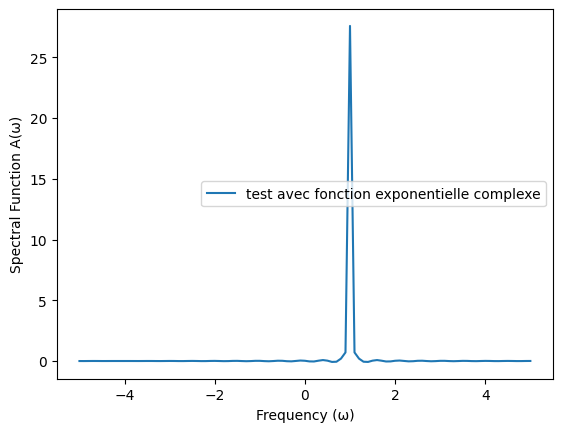

In [39]:
T = np.arange(0, 20/0.099, 0.62)

A_omega, G_omega = compute_spectral_function(T, [-1j*np.exp(-1j * t) for t in T], 1e-2, np.linspace(-5, 5, 101))
    
plt.plot(np.linspace(-5, 5, 101), A_omega, label="test avec fonction exponentielle complexe")

plt.xlabel("Frequency (ω)")
plt.ylabel("Spectral Function A(ω)")
plt.legend()
plt.show()

In [57]:
def retarded_green(h, t):
    psi0_mat = np.zeros((16,1), dtype=np.complex128)
    psi0_mat[2] = -0.301370506494539+0.2358429913952565j
    psi0_mat[8] = 0.7275642577484341-0.5693892799060466j
    psi0_mat = psi0_mat / np.linalg.norm(psi0_mat) #état fondamental donnée par HVA
    
    sigmaX = np.array([[0, 1], [1, 0]])
    sigmaY = np.array([[0, -1j], [1j, 0]])
    I = np.eye(2)
    
    c = 1/2 * np.kron(np.kron(np.kron(sigmaX + 1j * sigmaY, I), I), I)
    cdag = 1/2 * np.kron(np.kron(np.kron(sigmaX - 1j * sigmaY, I), I), I)
    
    matrix1 = h.get_matrix()
    eigvals, eigvectors = eigh(matrix)
    fondamental = np.transpose(eigvectors[:,0])
    iHt = 1j * t * matrix1
    expiHt = expm(iHt)
    exp_iHt = expm(-iHt)
    
    # Compute the anticommutator explicitly
    term1 = expiHt @ c @ exp_iHt @ cdag
    term2 =  cdag @ expiHt  @ c @ exp_iHt
    '''green = np.transpose(np.conj(fondamental)) @ (term1 + term2) @ fondamental'''
    green = np.transpose(np.conj(psi0_mat)) @ (term1 + term2) @ psi0_mat
    
    
    return -1j * green[0][0] if t >= 0 else 0.0

print(retarded_green(AndersonHamiltonian, 1))

(0.6984559986366086-0.1559436947653746j)


In [38]:
AndersonHamiltonian, matrixA = hamiltonian(1, 1, 1, 1, 1, [[1]], [1])

valeurs_prop, vecteurs_prop = np.linalg.eigh(AndersonHamiltonian.get_matrix())

print(vecteurs_prop[:, 0])

def matrice_creation(nqbits: int, i: int, spin: str):
    """ Calcule la matrice de l'opérateur c_{i, spin}.
    """
    if spin=="+":
        M = FermionHamiltonian(nqbits, [Term(1., "C", [i])]).to_spin().get_matrix()
        return M
    else:
        M = FermionHamiltonian(nqbits, [Term(1., "C", [i+1])]).to_spin().get_matrix()
        return M

def matrice_annihilation(nqbits: int, i: int, spin: str):
    """ Calcule la matrice de l'opérateur c^{dagger}_{i, spin}.
    """
    if spin=="+":
        M = FermionHamiltonian(nqbits, [Term(1., "c", [i])]).to_spin().get_matrix()
        return M
    else:
        M = FermionHamiltonian(nqbits, [Term(1., "c", [i+1])]).to_spin().get_matrix()
        return M

# fonction de Green selon la formule de Lehmann

# fonction de Green selon la formule de Lehmann

def Green_Lehmann(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], n_site_bain, Omega, eta):
    n_site = n_site_bain + 1
    n_qbits = 2 * n_site
    dim, nb_vp = np.shape(vecteurs_prop)
    
    mat_crea= matrice_creation(n_qbits, 0, "+")
    mat_nihil = matrice_annihilation(n_qbits, 0, "+")
    
    N = len(Omega)
    valeurs_prop = valeurs_prop - valeurs_prop[0]
    S = []
    for i in range(len(Omega)):
        S_i = 0
        for n in range(nb_vp):
            prod_scal1 = vecteurs_prop[:,0].T @ mat_crea @ vecteurs_prop[:,n]
            prod_scal1 = np.real(prod_scal1)**2 + np.imag(prod_scal1)** 2
            S_i += ( prod_scal1 ) / (
                       Omega[i] + valeurs_prop[n] - valeurs_prop[0]  - 1j * eta)
            
            prod_scal2 = vecteurs_prop[:,0].T @ mat_nihil @ vecteurs_prop[:,n]
            prod_scal2 = np.real(prod_scal2)**2 + np.imag(prod_scal2)** 2
            S_i += ( prod_scal2 ) / (
                         Omega[i] + valeurs_prop[0] - valeurs_prop[n] - 1j * eta )
        S.append(S_i)
    return S


def A_Lehman(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], n_site_bain, Omega, eta):
    return - 1 / np.pi * np.imag(Green_Lehmann(valeurs_prop, vecteurs_prop, n_site_bain, Omega, eta)) ## PARTIE IMAGINAIRE

[ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
 -2.11697992e-01+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
 -4.42174622e-01+0.j  0.00000000e+00+0.j -8.60447750e-17+0.j
  4.42174622e-01+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
 -7.51097309e-01+0.j -3.10608378e-49+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j]


In [39]:
def Gr_t(psi_0, i : int, sigma_i : str, j : int, sigma_j : str, h, t : float, N : int) :
    return  G_t_CDagC(psi_0, i, sigma_i, j, sigma_j, h, t, N) + G_t_CCDag(psi_0, i, sigma_i, j, sigma_j, h, t, N)

print(Gr_t(psi0, 0, "+", 0, "+", AndersonHamiltonian,  1, 10))

(0.28251722444900207-0.493530829112462j)


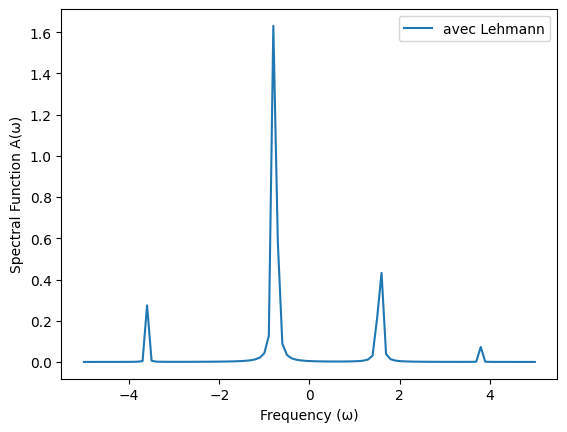

In [43]:
aLehmann = A_Lehman(valeurs_prop, vecteurs_prop, 1, np.linspace(-5, 5, 101), -1e-2)
plt.plot(np.linspace(-5, 5, 101), aLehmann, label="avec Lehmann")
plt.xlabel("Frequency (ω)")
plt.ylabel("Spectral Function A(ω)")
plt.legend()
plt.show()


Plus de valeurs temporelles positives

Ci-dessous la fonction de test avec le vrai état fondamental

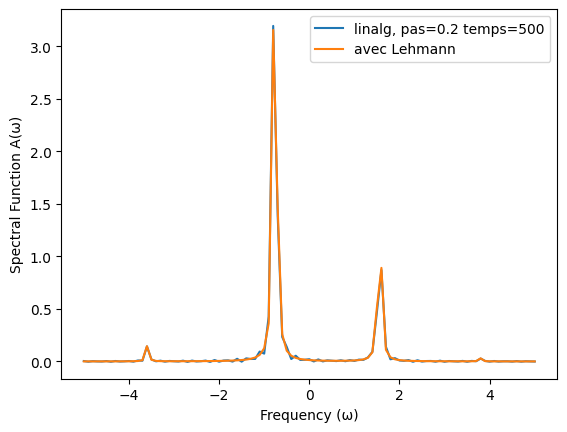

In [138]:
aLehmann = A_Lehman(valeurs_prop, vecteurs_prop, 1, np.linspace(-5, 5, 101), 3*-1e-2)
for pas in [0.2] :
    T = np.arange(0, 100, pas)
    
    A_omegaTest, G_omegaTest = compute_spectral_function(T, [retarded_green(AndersonHamiltonian,t) for t in T], 3*1e-2, np.linspace(-5, 5, 101))

    plt.plot(np.linspace(-5, 5, 101), A_omegaTest, label=f"linalg, pas={pas} temps={500}")

plt.plot(np.linspace(-5, 5, 101), aLehmann, label="avec Lehmann")
plt.xlabel("Frequency (ω)")
plt.ylabel("Spectral Function A(ω)")
plt.legend()
plt.show()

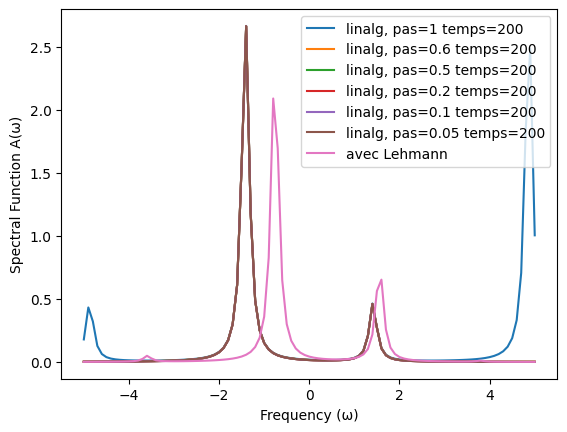

In [58]:
aLehmann = A_Lehman(valeurs_prop, vecteurs_prop, 1, np.linspace(-5, 5, 101), -1e-1)
for pas in [1, 0.6, 0.5, 0.2, 0.1, 0.05] :
    T = np.arange(0, 70, pas)

    A_omegaTest, G_omegaTest = compute_spectral_function(T, [retarded_green(AndersonHamiltonian, t) for t in T], 1e-1, np.linspace(-5, 5, 101))

    plt.plot(np.linspace(-5, 5, 101), A_omegaTest, label=f"linalg, pas={pas} temps={200}")

plt.plot(np.linspace(-5, 5, 101), aLehmann, label="avec Lehmann")
plt.xlabel("Frequency (ω)")
plt.ylabel("Spectral Function A(ω)")
plt.legend()
plt.show()

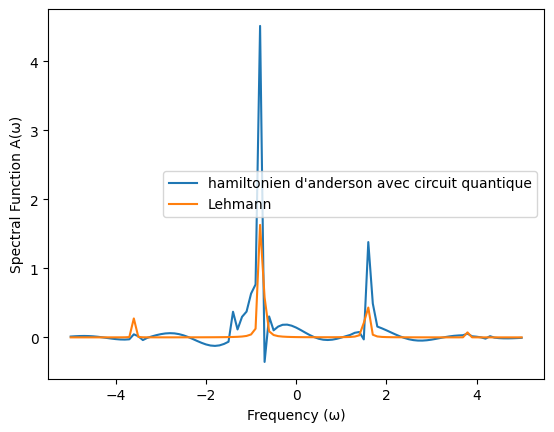

In [41]:
T = np.arange(0, 60, 0.5)
    
A_omega, G_omega = compute_spectral_function(T, [Gr_t(psi0, 0, "+", 0, "+", AndersonHamiltonian,  t, 400) for t in T], 1e-2, np.linspace(-5, 5, 101))
aLehmann = A_Lehman(valeurs_prop, vecteurs_prop, 1, np.linspace(-5, 5, 101), -1e-2)

    
plt.plot(np.linspace(-5, 5, 101), A_omega, label="hamiltonien d'anderson avec circuit quantique")
plt.plot(np.linspace(-5, 5, 101), aLehmann, label="Lehmann")
plt.xlabel("Frequency (ω)")
plt.ylabel("Spectral Function A(ω)")
plt.legend()
plt.show()

In [ ]:
T = np.arange(0, 85, 0.5)
    
A_omega, G_omega = compute_spectral_function(T, [Gr_t(psi0, 0, "+", 0, "+", AndersonHamiltonian,  t, 100) for t in T], 1e-2, np.linspace(-5, 5, 101))
aLehmann = A_Lehman(valeurs_prop, vecteurs_prop, 1, np.linspace(-5, 5, 101), -1e-2)

    
plt.plot(np.linspace(-5, 5, 101), A_omega, label="hamiltonien d'anderson avec circuit quantique")
plt.plot(np.linspace(-5, 5, 101), aLehmann, label="Lehmann")
plt.xlabel("Frequency (ω)")
plt.ylabel("Spectral Function A(ω)")
plt.legend()
plt.show()